# Phase F: Group comparisons

Reads per-file summary CSVs from Phases D and E; no raw data reloading.

-----------------------------------------------------------------------
Unit of analysis
-----------------------------------------------------------------------
The unit is one .sdt image file.  Each row in fit_analysis_summary.csv
represents one acquired field of view.  The fit metric values reported
(tau_mean_median_ps, amp_ratio_median) are the MEDIAN of quality-masked
pixels within that image -- not individual pixels.

Consequence: statistical tests compare image-level medians, which is
appropriate for detecting differences between cell populations but
underestimates within-image heterogeneity.

-----------------------------------------------------------------------
Like-for-like filtering (CRITICAL)
-----------------------------------------------------------------------
Mixing files fitted with different SPCImage models (2-comp vs 3-comp)
or with different IRF-shift modes (shift=0 vs shift!=0) produces
bimodal distributions that can wash out or reverse apparent effects.

ANALYSIS_N_COMP and ANALYSIS_SHIFT_GROUP (config below) restrict the
analysis to a homogeneous subset:
  ANALYSIS_N_COMP     -- preferred number of fit components per
                         fixation_type.  Files with a different n_comp
                         are excluded from df_analysis.
  ANALYSIS_SHIFT_GROUP -- "shift=0" | "shift!=0" | None.
                         Derived from fit_qc_summary.csv (Phase C).

The unfiltered df is retained for diagnostic steps (Steps 19b, 20, 23).
ALL group comparisons (Steps 21, 22, 24-27) use df_analysis.

-----------------------------------------------------------------------
Amplitude ratio definition (WARNING: raw ratio, not fraction)
-----------------------------------------------------------------------
amp_ratio is the RAW ratio of two SPCImage amplitude components:
  glu  : a2 / a3  (free NADH amplitude / bound NADH amplitude)
  form : a1 / a2  (free / bound)
  live : a1 / a2
Values are NOT bounded by [0, 1] -- for glu, typical a2/a3 ~ 1-5.
To get the normalised free-NADH fraction use amp_num / (amp_num + amp_den)
computed from the per-pixel maps in Phase E.
Violin plots and summary tables display the raw ratio.

-----------------------------------------------------------------------
tau_mean definition
-----------------------------------------------------------------------
tau_mean is the amplitude-weighted mean lifetime (ps) from Phase E.
  glu  : (a2*tau2 + a3*tau3) / (a2+a3)  -- artifact a1/tau1 excluded
  form : (a1*tau1 + a2*tau2) / (a1+a2)
  live : same as form
For glu files fitted with a 2-comp fallback, tau_mean is NaN because
the a3/tau3 components are absent.  Such files contribute NaN to
tau_mean_median_ps and are silently absent from tau_mean comparisons.

-----------------------------------------------------------------------
Statistical test
-----------------------------------------------------------------------
Step 22 uses a two-sided Mann-Whitney U test on per-image medians.
All pairwise cell_type combinations per (fixation_type, metric) block
are tested together; p-values are corrected with Benjamini-Hochberg FDR.
Effect size: rank-biserial r = 2U/(n1*n2) - 1.
  |r| < 0.3 small, 0.3-0.5 medium, > 0.5 large.
  Positive r: group_a tends to be larger than group_b.
Only cell_type groups with >= MIN_N images are included.

-----------------------------------------------------------------------
IRF drift and calibration sensitivity
-----------------------------------------------------------------------
The IRF (Instrument Response Function) encodes the timing jitter of the
TCSPC detector.  If the IRF peak shifts between sessions or during a
session, fitted lifetimes are systematically wrong by an amount that
scales with the shift.

Phase D (phasor): uses a per-session IRF calibration file measured each
  session.  Between-session IRF drift is therefore corrected.  Within-
  session drift is not corrected and broadens the phasor cloud.

Phase E (reconvolution fitting from SPCImage): this pipeline imports
  already-fitted parameters -- it does NOT re-fit or re-calibrate.
  Sensitivity to IRF drift depends entirely on which IRF file was used
  inside SPCImage:
    - If SPCImage used a SINGLE IRF file for all sessions, any session
      where the IRF had drifted will have systematically shifted lifetimes.
    - If SPCImage used PER-SESSION IRF files, between-session drift is
      corrected at the fitting stage.
  This pipeline cannot determine which was done.  Confirm with the
  SPCImage project files before interpreting inter-session differences.

The SPCImage "shift" parameter (shift=0 vs shift!=0) is an in-fitting
  correction for IRF timing offset.  shift=0 files absorbed any timing
  offset into the lifetime values.  shift!=0 files corrected for it but
  introduce a correlated free parameter that can cause bimodal tau
  distributions (two local minima for shift vs tau).

-----------------------------------------------------------------------
Inter-session confounding (CRITICAL WARNING)
-----------------------------------------------------------------------
Step 19b checks for bimodality by imaging session.  If tau_mean_median_ps
separates strongly by session_root, the comparison may be confounded:

  Fixed samples (glu, form): fixation time, fixation protocol, and
    fixative concentration can vary between sessions.  Different fixation
    times alter the fraction of bound vs free NADH independently of
    genotype.  If different genotypes were predominantly imaged in
    different sessions, session is a confound for genotype.

  Live samples: if only one cell type was imaged per session, session
    and cell_type are completely confounded and no statistical comparison
    is possible without a session-corrected model (e.g., mixed effects).

BEFORE interpreting any group differences:
  1. Check which sessions each cell type appears in.
  2. If there is no within-session replication across genotypes, the
     group comparison is not interpretable.
  3. If session bimodality is present, consult the experimental log to
     determine whether fixation conditions differed.

-----------------------------------------------------------------------
Known limitations and cautions
-----------------------------------------------------------------------
1. Pseudo-replication: pixels within one image are spatially correlated
   (SPCImage bins over (2b+1)^2 neighborhoods).  Using per-image medians
   avoids this.  But multiple images from the same dish are not fully
   independent -- no dish-level random effect is modeled.

2. Asymmetric tau_mean filter in Phase E: live images apply an extra
   tau_mean >= 250 ps criterion that glu and form do not.  This may
   affect the live distribution shape relative to fixed conditions.

3. Photobleaching: Step 20 checks for metric drift within a session.
   If drift is detected, acquisition order should be treated as a
   covariate or early/late acquisitions excluded before final analysis.

4. n_components column in fit_analysis_summary.csv: parsed from the fit
   folder name string (e.g. "fitet-sf-3component-b5" -> 3).  If the
   folder uses an older naming scheme ("c2", "c3") the regex may fail
   and n_components will be None.  Check the distribution printout in
   Step 19 before interpreting ANALYSIS_N_COMP filtering.

5. ANALYSIS_SHIFT_GROUP is now a per-fixation-type dict.  If all files
   of a given fixation_type were fitted with a free shift in SPCImage
   (shift!=0), a "shift=0" filter silently excludes all of them.  A
   WARNING is printed in Step 19 when this happens.

-----------------------------------------------------------------------
Steps
-----------------------------------------------------------------------
19.  Load and merge Phase D/E summaries; report coverage
19b. Bimodality diagnosis (unfiltered): session, fit model, calibration
20.  Photobleaching check: metrics vs acquisition_time within session
21.  Violin plots: tau_mean and amplitude ratio grouped by cell_type
22.  Pairwise statistical tests: Mann-Whitney U with BH-FDR
23.  Phasor vs fit cross-validation: tau_phi vs tau_mean scatter
24.  Group summary table -> results/group_summary.csv
25.  Per-channel comparison (em_filter_nm facets)
26-27. Additional diagnostic plots

In [1]:
from pathlib import Path
import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# -- Configuration ----------------------------------------------------------
# Cell types and fixation types to include, in display order
CELL_TYPE_ORDER = ["KPCWT", "BKO", "DKO"]
FIXATION_ORDER  = ["glu", "form", "live"]

# Figure output
FIGURES_DIR  = Path("../results/figures")
SAVE_FIGURES = True   # set False to skip saving


def _savefig(fig, name: str) -> None:
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

# Minimum images per group to include in statistical tests
MIN_N = 3

# FDR threshold for significance marking
FDR_ALPHA = 0.05

# Metrics from Phase E (fit) and Phase D (phasor) to analyse
FIT_METRICS    = ["tau_mean_median_ps", "amp_ratio_median"]
PHASOR_METRICS = ["tau_phi_ns", "tau_mod_ns", "G_cal_wmean", "S_cal_wmean"]

METRIC_LABELS = {
    "tau_mean_median_ps": "tau_mean median (ps)",
    # glu: a2/(a2+a3) free/bound NADH ratio (artifact component excluded)
    # form/live: a1/(a1+a2) free/bound NADH ratio
    "amp_ratio_median":   "amp ratio (median)",
    "tau_phi_ns":         "tau_phi (ns)",
    "tau_mod_ns":         "tau_mod (ns)",
    "G_cal_wmean":        "G_cal (photon-weighted mean)",
    "S_cal_wmean":        "S_cal (photon-weighted mean)",
}

# Restrict group comparisons to a single fit model so every violin contains
# only like-for-like measurements.  Mixing n_comp or shift groups produces
# bimodal distributions that wash out any biological signal.
#
# ANALYSIS_N_COMP: preferred n_components per fixation_type.
#   Files where best_fit_key() resolved to a different n_comp are excluded.
#   Set a value to None to include all n_comp variants for that fixation_type.
ANALYSIS_N_COMP = {"glu": 3, "form": 2, "live": 2}

# ANALYSIS_SHIFT_GROUP: per-fixation-type dict.
#   Value: "shift=0" | "shift!=0" | None (no filter for that type).
#   Derived from fit_qc_summary.csv (Phase C shift_nonzero_px column).
#   If fit_qc_summary.csv is absent, all files are treated as "shift=0".
#
#   IMPORTANT: if all files of a given fixation_type were fitted with a
#   free IRF shift in SPCImage (shift!=0), setting that type to "shift=0"
#   will produce an empty analysis group.  Check the shift breakdown printed
#   in Step 19 before changing these values.
#
#   Typical reasons all live files end up as shift!=0:
#     - SPCImage was configured with shift=free for the live acquisition set
#     - The live IRF timing offset was consistently non-zero across sessions
#   In that case set live to "shift!=0" to retain those files, but note that
#   the shift parameter correlates with the fitted lifetimes (see header).
ANALYSIS_SHIFT_GROUP = {
    "glu":  "shift=0",
    "form": "shift=0",
    "live": "shift=0",  # best_fit_key now prefers sz folders; check WARNING in Step 19
}

# Pockels-cell voltage filter.
# Metadata shows a confirmed two-cluster distribution: low cluster <= 0.25,
# high cluster >= 0.45 (gap of 0.20).  High pockels = lower irradiance per
# pixel -> fewer photons -> shifted fitted lifetime.  Mixing clusters can
# reverse the apparent BKO vs KPCWT direction.
# Set None to disable (includes all pockels values).
MAX_POCKELS = 0.25

# Z-stack first-slice filter.
# OpenScan saves one .sdt file per shutter close (one per z-step), so the
# frame_index column encodes z-stack depth (0 = first slice, 1 = second, ...).
# When True, live acquisitions are restricted to frame_index=0 so each
# physical position contributes exactly one data point.
# Set False to include all z-slices.
LIVE_FIRST_FRAME_ONLY = True

# Sessions to exclude from specific fixation types.
# Format: {session_root_prefix: [fixation_type, ...]} or {session_root_prefix: None} to
# exclude all fixation types from that session.
# 20260501 live: IRF peak shifted 2-3 time bins during the PM (live) acquisition.
# With sz (shift fixed to zero) the shift is absorbed into the lifetime components,
# biasing tau_mean upward (~881 ps vs ~747 ps for the next KPCWT live session).
EXCLUDE_SESSION_FT = {
    "20260501_KPC_fixed_dishes_on_SLIM": ["live"],
}

## Step 19: Load and merge summaries

In [2]:
results_dir = Path("../results")

sdt_df = pd.read_csv(results_dir / "sdt_metadata_cal.csv")
sdt_df["acquisition_time"] = pd.to_datetime(sdt_df["acquisition_time"])

fit_df    = pd.read_csv(results_dir / "fit_analysis_summary.csv")
phasor_df = pd.read_csv(results_dir / "sdt_phasor_summary.csv")

# Join phasor columns onto fit summary (outer join to keep files with only one)
phasor_cols = ["filename", "tau_phi_ns", "tau_mod_ns",
               "G_cal_wmean", "S_cal_wmean", "M_wmean",
               "n_px_masked"]
df = fit_df.merge(
    phasor_df[phasor_cols].rename(columns={"n_px_masked": "n_px_phasor"}),
    on="filename", how="outer",
)

# Always pull acquisition_time, pockels, frame_index from sdt_df.
# fit_analysis_summary.csv often comes back from Excel with datetime columns
# truncated to "MM:SS.f" time-only strings, so any pre-existing values are
# unreliable -- drop them and re-merge from sdt_df.
df = df.drop(columns=["acquisition_time", "pockels", "frame_index"], errors="ignore")
df = df.merge(
    sdt_df[["filename", "acquisition_time", "pockels", "frame_index"]],
    on="filename", how="left",
)
# sdt_df["acquisition_time"] was parsed to datetime at load time.

# Merge position annotations
annot_path = results_dir / "position_annotation.csv"
if annot_path.exists():
    annot_df = pd.read_csv(annot_path)
    df = df.merge(
        annot_df[["filename", "annotation"]].rename(
            columns={"annotation": "position_annotation"}
        ),
        on="filename", how="left",
    )
    df["position_annotation"] = df["position_annotation"].fillna("(unannotated)")
else:
    df["position_annotation"] = "(unannotated)"

# Apply session exclusions defined in EXCLUDE_SESSION_FT
if EXCLUDE_SESSION_FT and "session_root" in df.columns:
    _n_before_excl = len(df)
    for _sess_excl, _ft_excl in EXCLUDE_SESSION_FT.items():
        _sess_mask = df["session_root"].str.startswith(_sess_excl, na=False)
        if _ft_excl is None:
            _drop_mask = _sess_mask
        else:
            _drop_mask = _sess_mask & df["fixation_type"].isin(_ft_excl)
        _n_drop = _drop_mask.sum()
        if _n_drop:
            _fts = "all" if _ft_excl is None else "/".join(_ft_excl)
            print(f"EXCLUDE_SESSION_FT: dropping {_n_drop} rows"
                  f" ({_sess_excl}, {_fts})")
        df = df[~_drop_mask].copy()
    print(f"  {_n_before_excl} -> {len(df)} rows after session exclusions")

print(f"Combined dataframe: {len(df)} rows")
print("\nCoverage by fixation_type x cell_type:")
print(df.groupby(["fixation_type", "cell_type"], dropna=False).size().to_string())

# Session x cell_type cross-tab: printed here as an early confounding check.
# If each cell type appears ONLY in its own session(s) the comparison is
# confounded -- any group difference could be a session/batch effect.
print("\nSession x cell_type (files per cell): check for session/genotype confounding")
if "session_root" in df.columns and "cell_type" in df.columns:
    _xtab = (df.groupby(["fixation_type", "session_root", "cell_type"], dropna=False)
               .size()
               .unstack("cell_type", fill_value=0))
    print(_xtab.to_string())
    _ct_cols = [c for c in CELL_TYPE_ORDER if c in _xtab.columns]
    for _ft in FIXATION_ORDER:
        _sub_xt = _xtab[_xtab.index.get_level_values("fixation_type") == _ft][_ct_cols]
        if _sub_xt.empty:
            continue
        # A session is "confounded" if only one cell type has > 0 files in that session
        _confounded = [idx for idx in _sub_xt.index
                       if (_sub_xt.loc[idx] > 0).sum() < 2]
        if _confounded:
            print(f"  CAUTION [{_ft}]: {len(_confounded)} session(s) have only "
                  f"one cell type -- session and genotype are partially confounded.")

print("\nMetric availability:")
all_metrics = [m for m in FIT_METRICS + PHASOR_METRICS if m in df.columns]
for m in all_metrics:
    print(f"  {m:30s}: {df[m].notna().sum()}/{len(df)}")

EXCLUDE_SESSION_FT: dropping 42 rows (20260501_KPC_fixed_dishes_on_SLIM, live)
  647 -> 605 rows after session exclusions
Combined dataframe: 605 rows

Coverage by fixation_type x cell_type:
fixation_type  cell_type
form           BKO          132
               KPCWT        113
glu            BKO           56
               KPCWT         50
live           BKO          130
               KPCWT         53
NaN            NaN           71

Session x cell_type (files per cell): check for session/genotype confounding
cell_type                                        BKO  KPCWT  NaN
fixation_type session_root                                      
form          20260509_KPC_fixed_dishes_on_SLIM   64     47    0
              20260520_KPC_fixed_dishes_SLIM      68     66    0
glu           20260501_KPC_fixed_dishes_on_SLIM   30     20    0
              20260522_KPC_fixed_dishes_SLIM      26     30    0
live          20260508_KPC_live_on_SLIM            0     53    0
              20260517_KPC_

In [3]:
# -- Parse n_components and shift_group from fit metadata -------------------
#
# n_components: Phase E (Step 18) now writes an explicit n_components column
#   to fit_analysis_summary.csv.  Use it directly when present; fall back to
#   regex parsing of fit_set_key for older CSV files that lack the column.
#   Regex rules:
#     "...fitet-sf-3component-b5..." -> 3
#     "...fitet-sf-c2-b3..."        -> 2
#
# shift_group: merged from fit_qc_summary.csv (Phase C output).
#   shift_nonzero_px > 0 means SPCImage used a free IRF shift.
#   If fit_qc_summary.csv is absent, every file is labelled "shift=0".

def _parse_n_comp_from_key(key):
    if not isinstance(key, str):
        return np.nan
    m = re.search(r"[-_](\d+)component", key, re.IGNORECASE)
    if m:
        return float(m.group(1))
    m = re.search(r"[-_]c(\d+)(?=[-_b]|$)", key, re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

# Prefer the explicit column; fall back to key-string parsing
if "n_components" not in df.columns or df["n_components"].isna().all():
    df["n_components"] = df["fit_set_key"].apply(_parse_n_comp_from_key)
    print("n_components: parsed from fit_set_key string (no explicit column found)")
else:
    # Fill any gaps with key-string parsing
    _missing = df["n_components"].isna()
    if _missing.any():
        df.loc[_missing, "n_components"] = (
            df.loc[_missing, "fit_set_key"].apply(_parse_n_comp_from_key)
        )
    print("n_components: using explicit column from fit_analysis_summary.csv")

qc_path = results_dir / "fit_qc_summary.csv"
if qc_path.exists():
    _qc = pd.read_csv(qc_path)[["filename", "shift_nonzero_px"]].drop_duplicates("filename")
    df  = df.merge(_qc, on="filename", how="left")
    df["shift_group"] = df["shift_nonzero_px"].apply(
        lambda x: "shift!=0" if (pd.notna(x) and float(x) > 0) else "shift=0"
    )
    print(f"\nShift groups merged from fit_qc_summary.csv:")
    print(df.groupby(["fixation_type", "shift_group"], dropna=False).size().to_string())
else:
    df["shift_group"] = "shift=0"
    print("\nfit_qc_summary.csv not found; all files treated as shift=0")

print("\nn_components distribution:")
print(df.groupby(["fixation_type", "n_components"], dropna=False).size().to_string())

n_components: using explicit column from fit_analysis_summary.csv

Shift groups merged from fit_qc_summary.csv:
fixation_type  shift_group
form           shift=0        245
glu            shift!=0       106
live           shift=0        183
NaN            shift=0         71

n_components distribution:
fixation_type  n_components
form           2.0             245
glu            3.0             106
live           2.0             183
NaN            NaN              71


In [4]:
# -- Filter to like-for-like analysis subset --------------------------------
#
# Drop files that don't match ANALYSIS_N_COMP or ANALYSIS_SHIFT_GROUP so that
# violins and statistical tests compare only homogeneous fit populations.
# Stored as df_analysis; the raw df is kept for diagnostics (Steps 19b, 20, 23).

df_analysis = df.copy()

if ANALYSIS_N_COMP:
    for fix_type, preferred_nc in ANALYSIS_N_COMP.items():
        if preferred_nc is None:
            continue
        mask_ok = (
            (df_analysis["fixation_type"] != fix_type) |
            df_analysis["n_components"].isna() |
            (df_analysis["n_components"] == preferred_nc)
        )
        n_drop = (~mask_ok).sum()
        if n_drop > 0:
            print(f"  n_comp filter: dropped {n_drop} {fix_type} rows"
                  f" not matching {preferred_nc}-comp")
        df_analysis = df_analysis[mask_ok]

if isinstance(ANALYSIS_SHIFT_GROUP, dict):
    # Per-fixation-type shift filter
    for fix_type, sg_val in ANALYSIS_SHIFT_GROUP.items():
        if sg_val is None:
            continue
        mask_shift = (
            (df_analysis["fixation_type"] != fix_type) |
            df_analysis["shift_group"].isna() |
            (df_analysis["shift_group"] == sg_val)
        )
        n_drop = (~mask_shift).sum()
        if n_drop > 0:
            print(f"  shift filter [{fix_type}]: dropped {n_drop} rows"
                  f" not in '{sg_val}'")
        df_analysis = df_analysis[mask_shift]
elif ANALYSIS_SHIFT_GROUP is not None:
    # Global shift filter (legacy scalar)
    mask_shift = (
        df_analysis["shift_group"].isna() |
        (df_analysis["shift_group"] == ANALYSIS_SHIFT_GROUP)
    )
    n_drop = (~mask_shift).sum()
    if n_drop > 0:
        print(f"  shift filter: dropped {n_drop} rows not in '{ANALYSIS_SHIFT_GROUP}'")
    df_analysis = df_analysis[mask_shift]

# -- Pockels filter -----------------------------------------------------------
if MAX_POCKELS is not None and "pockels" in df_analysis.columns:
    _n_hi_poc = (df_analysis["pockels"] > MAX_POCKELS).sum()
    if _n_hi_poc:
        print(f"  pockels filter: dropped {_n_hi_poc} rows"
              f" with pockels > {MAX_POCKELS}")
    df_analysis = df_analysis[df_analysis["pockels"] <= MAX_POCKELS].copy()
    print("\nPockels distribution after filter (all rows in df_analysis):")
    print(df_analysis["pockels"].value_counts(dropna=False).sort_index().to_string())
elif "pockels" not in df_analysis.columns:
    print("  WARNING: pockels column not found - MAX_POCKELS filter skipped.")

# -- Z-stack first-slice filter -----------------------------------------------
# Restricts LIVE acquisitions to frame_index=0 (first z-slice) so each
# physical position contributes exactly one row.  Form and glu acquisitions
# are single focal planes and are not filtered.
if LIVE_FIRST_FRAME_ONLY and "frame_index" in df_analysis.columns:
    _live_mask = df_analysis["fixation_type"] == "live"
    _n_frames_drop = (_live_mask & (df_analysis["frame_index"] > 0)).sum()
    if _n_frames_drop:
        print(f"  frame_index filter: dropped {_n_frames_drop} live rows"
              f" with frame_index > 0 (z-slice >= 1)")
    df_analysis = df_analysis[
        ~_live_mask | (df_analysis["frame_index"] == 0)
    ].copy()
elif LIVE_FIRST_FRAME_ONLY and "frame_index" not in df_analysis.columns:
    print("  WARNING: frame_index column not found - LIVE_FIRST_FRAME_ONLY filter skipped.")

print(f"\nAnalysis dataset: {len(df_analysis)} rows  "
      f"(from {len(df)} total; "
      f"n_comp={ANALYSIS_N_COMP}, shift={ANALYSIS_SHIFT_GROUP})")
print(df_analysis.groupby(["fixation_type", "cell_type"], dropna=False).size().to_string())

# Warn loudly if any fixation_type is completely absent after filtering
for _ft in FIXATION_ORDER:
    _n_ft = (df_analysis["fixation_type"] == _ft).sum()
    _n_before = (df["fixation_type"] == _ft).sum()
    if _n_before > 0 and _n_ft == 0:
        print(f"\n  WARNING: {_ft} has 0 rows in df_analysis (was {_n_before} before filtering).")
        print(f"    Check ANALYSIS_N_COMP['{_ft}'] and ANALYSIS_SHIFT_GROUP['{_ft}'].")
        _ft_sg = df[df["fixation_type"] == _ft]["shift_group"].value_counts()
        _ft_nc = df[df["fixation_type"] == _ft]["n_components"].value_counts()
        print(f"    shift_group distribution:\n{_ft_sg.to_string()}")
        print(f"    n_components distribution:\n{_ft_nc.to_string()}")

# Convenience subsets derived from the filtered dataset
fix_present = [f for f in FIXATION_ORDER  if f in df_analysis["fixation_type"].dropna().unique()]
ct_present  = [c for c in CELL_TYPE_ORDER if c in df_analysis["cell_type"].dropna().unique()]

# -- Snapshot for regression testing -----------------------------------------
# When FLIM_SNAPSHOT is set, dump df and df_analysis to tests/snapshots/.
# Used by tests/compare_outputs.py during the notebook -> library refactor.
import os as _os
if _os.environ.get("FLIM_SNAPSHOT"):
    _snap = Path("../tests/snapshots"); _snap.mkdir(parents=True, exist_ok=True)
    df.to_pickle(_snap / "phaseF_df.pkl")
    df_analysis.to_pickle(_snap / "phaseF_df_analysis.pkl")
    print(f"FLIM_SNAPSHOT: wrote phaseF_df.pkl, phaseF_df_analysis.pkl to {_snap}")

  shift filter [glu]: dropped 106 rows not in 'shift=0'
  pockels filter: dropped 210 rows with pockels > 0.25

Pockels distribution after filter (all rows in df_analysis):
pockels
0.10      1
0.15      3
0.20    105
0.25    180
  frame_index filter: dropped 107 live rows with frame_index > 0 (z-slice >= 1)

Analysis dataset: 182 rows  (from 605 total; n_comp={'glu': 3, 'form': 2, 'live': 2}, shift={'glu': 'shift=0', 'form': 'shift=0', 'live': 'shift=0'})
fixation_type  cell_type
form           BKO          66
               KPCWT        58
live           BKO           6
               KPCWT         5
NaN            NaN          47

    Check ANALYSIS_N_COMP['glu'] and ANALYSIS_SHIFT_GROUP['glu'].
    shift_group distribution:
shift_group
shift!=0    106
    n_components distribution:
n_components
3.0    106
FLIM_SNAPSHOT: wrote phaseF_df.pkl, phaseF_df_analysis.pkl to ..\tests\snapshots


In [5]:
# -- Step 19c: Numeric group summary ----------------------------------------
#
# Median, mean, SD, and n for every metric broken down by
# (fixation_type, em_filter_nm, cell_type).  Use this table to cross-check
# violin plots and compare against prior runs.  Printed before any figures
# so it is visible even if a later cell crashes.

print("=" * 72)
print("NUMERIC GROUP SUMMARY  (df_analysis -- like-for-like filtered)")
print("=" * 72)

_grp_cols_19c = [c for c in ["fixation_type", "em_filter_nm", "cell_type"]
                 if c in df_analysis.columns]

for _m in all_metrics:
    _lbl = METRIC_LABELS.get(_m, _m)
    _sub19 = df_analysis[_grp_cols_19c + [_m]].dropna(subset=[_m])
    if _sub19.empty:
        continue
    _agg19 = (_sub19.groupby(_grp_cols_19c, dropna=False)[_m]
              .agg(n="count", median="median", mean="mean", std="std")
              .round(1))
    print(f"\n{_lbl}  [{_m}]")
    print(_agg19.to_string())

    # Direction: which cell_type has the higher median per (fix, channel)?
    print("  Direction (descending median):")
    _chans19 = sorted(df_analysis["em_filter_nm"].dropna().unique())
    for _ft19 in fix_present:
        for _ch19 in _chans19:
            _meds = {}
            for _ct19 in ct_present:
                _v19 = df_analysis[
                    (df_analysis["fixation_type"] == _ft19) &
                    (df_analysis["em_filter_nm"]  == _ch19) &
                    (df_analysis["cell_type"]     == _ct19)
                ][_m].dropna()
                if len(_v19) >= 2:
                    _meds[_ct19] = float(_v19.median())
            if len(_meds) >= 2:
                _sorted19 = sorted(_meds.items(), key=lambda kv: -kv[1])
                _dir19 = " > ".join(f"{k}({v:.1f})" for k, v in _sorted19)
                print(f"    {_ft19} / {_ch19} nm: {_dir19}")

print("\n" + "=" * 72)

NUMERIC GROUP SUMMARY  (df_analysis -- like-for-like filtered)

tau_mean median (ps)  [tau_mean_median_ps]
                                       n  median   mean   std
fixation_type em_filter_nm cell_type                         
form          457.0        BKO        33   570.0  543.9  53.8
                           KPCWT      29   552.1  544.1  34.1
              535.0        BKO        33   583.2  569.1  56.8
                           KPCWT      29   574.9  562.2  31.1
live          457.0        BKO         4   620.2  623.0  17.1
                           KPCWT       3   757.6  756.1  28.4
              535.0        BKO         2   535.1  535.1  11.3
                           KPCWT       2   728.9  728.9  10.9
  Direction (descending median):
    form / 457.0 nm: BKO(570.0) > KPCWT(552.1)
    form / 535.0 nm: BKO(583.2) > KPCWT(574.9)
    live / 457.0 nm: KPCWT(757.6) > BKO(620.2)
    live / 535.0 nm: KPCWT(728.9) > BKO(535.1)

amp ratio (median)  [amp_ratio_median]
            

In [6]:
# -- Step 19d: Per-session breakdown (session x channel x cell_type) ---------
#
# Median per (fixation_type, em_filter_nm, session_root, cell_type).
# Uses df_analysis which is already filtered to shift=0 and preferred n_comp,
# so session-size imbalances between cell_types cannot skew the aggregate.
# If a session contains only one cell_type the comparison is confounded --
# any group difference in that fixation_type could be a batch effect.

print("=" * 72)
print("PER-SESSION BREAKDOWN  (df_analysis: shift=0, preferred n_comp)")
print("=" * 72)

_sd_cols = [c for c in ["fixation_type", "em_filter_nm", "session_root", "cell_type"]
            if c in df_analysis.columns]

for _m in all_metrics:
    _lbl = METRIC_LABELS.get(_m, _m)
    _sub_sd = df_analysis[_sd_cols + [_m]].dropna(subset=[_m])
    if _sub_sd.empty:
        continue
    _agg_sd = (_sub_sd.groupby(_sd_cols, dropna=False)[_m]
               .agg(n="count", median="median")
               .round(1))
    print(f"\n{_lbl}  [{_m}]")
    print(_agg_sd.to_string())

# Confounding summary (independent of metric)
if "session_root" in df_analysis.columns:
    print("\nSession/cell_type overlap per fixation_type:")
    for _ft_s in fix_present:
        _sub_ft = df_analysis[df_analysis["fixation_type"] == _ft_s]
        _sess_ct = (_sub_ft.groupby(["session_root", "cell_type"], dropna=False)
                    .size().unstack("cell_type", fill_value=0))
        _ct_cols_s = [c for c in ct_present if c in _sess_ct.columns]
        if len(_ct_cols_s) < 2:
            print(f"  {_ft_s}: only one cell_type present -- cannot assess overlap")
            continue
        _n_both  = (_sess_ct[_ct_cols_s] > 0).all(axis=1).sum()
        _n_total = len(_sess_ct)
        if _n_both == 0:
            print(f"  {_ft_s}: FULLY CONFOUNDED -- 0/{_n_total} sessions"
                  f" contain both cell_types")
        elif _n_both < _n_total:
            print(f"  {_ft_s}: PARTIAL -- {_n_both}/{_n_total} sessions"
                  f" contain both cell_types")
        else:
            print(f"  {_ft_s}: OK -- all {_n_total} sessions contain both cell_types")

print("\n" + "=" * 72)

PER-SESSION BREAKDOWN  (df_analysis: shift=0, preferred n_comp)

tau_mean median (ps)  [tau_mean_median_ps]
                                                                         n  median
fixation_type em_filter_nm session_root                      cell_type            
form          457.0        20260509_KPC_fixed_dishes_on_SLIM BKO        16   493.3
                                                             KPCWT      12   509.1
                           20260520_KPC_fixed_dishes_SLIM    BKO        17   595.2
                                                             KPCWT      17   562.1
              535.0        20260509_KPC_fixed_dishes_on_SLIM BKO        16   508.8
                                                             KPCWT      12   530.0
                           20260520_KPC_fixed_dishes_SLIM    BKO        17   625.2
                                                             KPCWT      17   587.2
live          457.0        20260508_KPC_live_on_SLIM         K


G_cal (photon-weighted mean)  [G_cal_wmean]
                                                                         n  median
fixation_type em_filter_nm session_root                      cell_type            
form          457.0        20260509_KPC_fixed_dishes_on_SLIM BKO        16     0.5
                                                             KPCWT      12     0.5
                           20260520_KPC_fixed_dishes_SLIM    BKO        17     0.5
                                                             KPCWT      17     0.5
              535.0        20260509_KPC_fixed_dishes_on_SLIM BKO        16     0.5
                                                             KPCWT      12     0.5
                           20260520_KPC_fixed_dishes_SLIM    BKO        17     0.5
                                                             KPCWT      17     0.5
live          457.0        20260508_KPC_live_on_SLIM         KPCWT       3     0.5
                           20260517_KPC_li

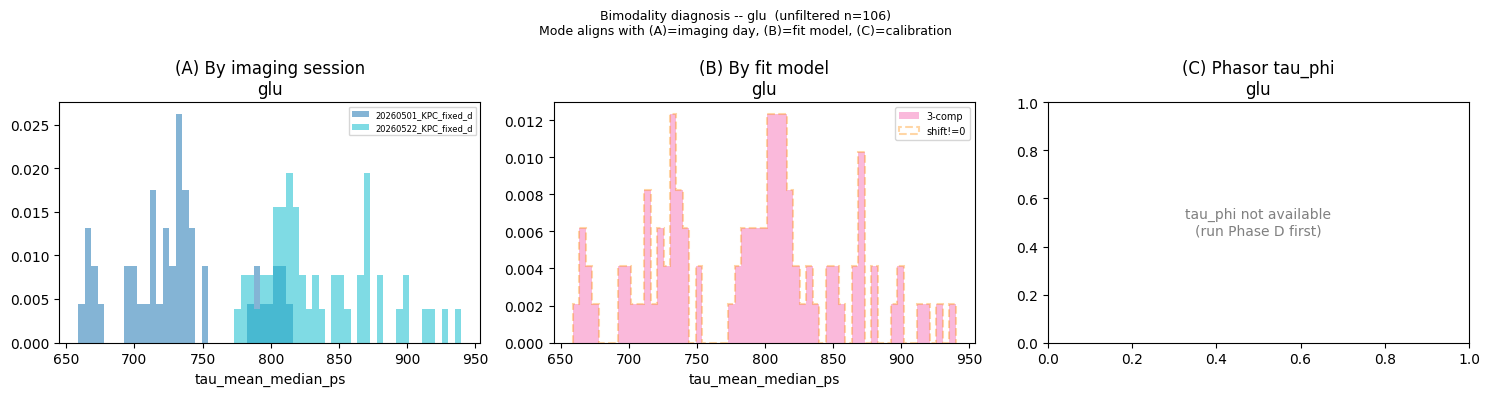

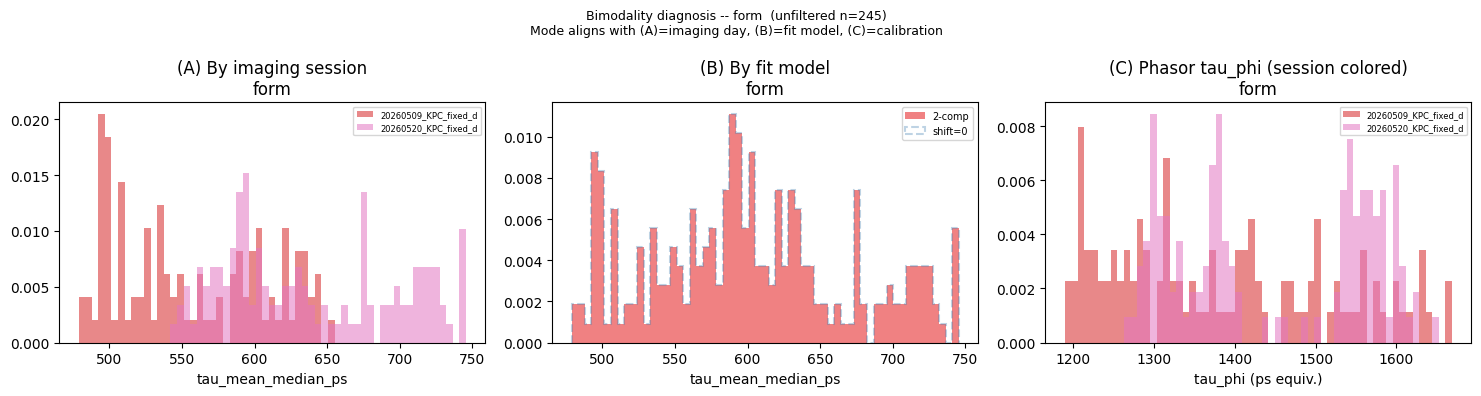

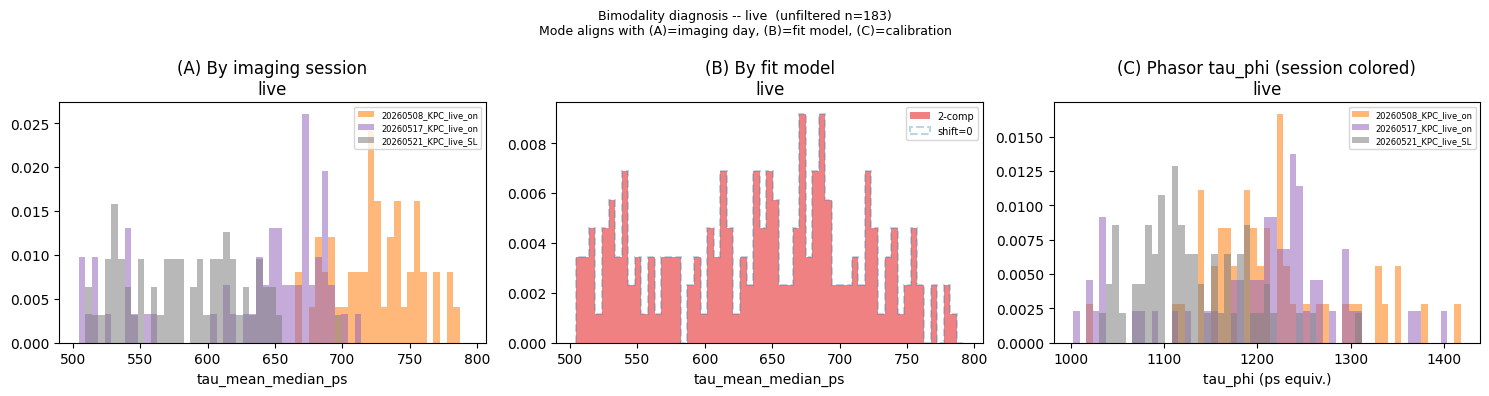

In [7]:
# -- Step 19b: Bimodality diagnosis -----------------------------------------
#
# Before group comparison, test the three hypotheses for bimodal distributions:
#   (A) Imaging day    -- color by session_root
#   (B) Fit model mix  -- color by n_components or shift_group
#   (C) Calibration    -- compare phasor tau_phi with fit tau_mean; if both
#       are bimodal and modes map to sessions, suspect calibration drift.
#
# Uses the UNFILTERED df so session/model mixing is visible before filtering.

_diag_metric = "tau_mean_median_ps"
if _diag_metric in df.columns and df[_diag_metric].notna().any():
    _sessions  = sorted(df["session_root"].dropna().unique())
    _n_comps   = sorted(df["n_components"].dropna().unique())
    _sgroups   = sorted(df["shift_group"].dropna().unique())
    _s_cmap    = plt.cm.tab10(np.linspace(0, 0.9, max(len(_sessions), 1)))
    _nc_cmap   = plt.cm.Set1(np.linspace(0, 0.8, max(len(_n_comps), 1)))
    _sg_colors = {"shift=0": "steelblue", "shift!=0": "darkorange"}

    for _ft in [f for f in FIXATION_ORDER if f in df["fixation_type"].dropna().unique()]:
        _sub = df[(df["fixation_type"] == _ft) & df[_diag_metric].notna()]
        if _sub.empty:
            continue
        _vals_all = _sub[_diag_metric].values
        _lo = float(np.percentile(_vals_all, 1))
        _hi = float(np.percentile(_vals_all, 99))
        _bins = np.linspace(_lo, _hi, 60)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # (A) By imaging session
        for i, sess in enumerate(_sessions):
            v = _sub[_sub["session_root"] == sess][_diag_metric].values
            if v.size > 0:
                axes[0].hist(v, bins=_bins, alpha=0.55, density=True,
                             color=_s_cmap[i], label=sess[:20])
        axes[0].set_title(f"(A) By imaging session\n{_ft}")
        axes[0].set_xlabel(_diag_metric)
        axes[0].legend(fontsize=6, loc="upper right")

        # (B) By fit model (n_comp and shift_group)
        for nc in _n_comps:
            v = _sub[_sub["n_components"] == nc][_diag_metric].values
            if v.size > 0:
                nc_idx = list(_n_comps).index(nc)
                axes[1].hist(v, bins=_bins, alpha=0.55, density=True,
                             color=_nc_cmap[nc_idx], label=f"{int(nc)}-comp")
        for sg in _sgroups:
            v = _sub[_sub["shift_group"] == sg][_diag_metric].values
            if v.size > 0:
                axes[1].hist(v, bins=_bins, alpha=0.35, density=True,
                             color=_sg_colors.get(sg, "gray"),
                             linestyle="--", histtype="step",
                             linewidth=1.5, label=sg)
        axes[1].set_title(f"(B) By fit model\n{_ft}")
        axes[1].set_xlabel(_diag_metric)
        axes[1].legend(fontsize=7, loc="upper right")

        # (C) Phasor vs fit: if phasor tau_phi is also bimodal,
        #     and modes map to sessions, it is a calibration issue.
        if "tau_phi_ns" in _sub.columns and _sub["tau_phi_ns"].notna().any():
            _phi_vals = _sub["tau_phi_ns"].dropna().values * 1000  # ns -> ps equivalent
            _phi_lo   = float(np.percentile(_phi_vals, 1))
            _phi_hi   = float(np.percentile(_phi_vals, 99))
            for i, sess in enumerate(_sessions):
                v = _sub[_sub["session_root"] == sess]["tau_phi_ns"].dropna().values * 1000
                if v.size > 0:
                    axes[2].hist(v, bins=np.linspace(_phi_lo, _phi_hi, 60),
                                 alpha=0.55, density=True,
                                 color=_s_cmap[i], label=sess[:20])
            axes[2].set_title(f"(C) Phasor tau_phi (session colored)\n{_ft}")
            axes[2].set_xlabel("tau_phi (ps equiv.)")
            axes[2].legend(fontsize=6, loc="upper right")
        else:
            axes[2].text(0.5, 0.5, "tau_phi not available\n(run Phase D first)",
                         ha="center", va="center", transform=axes[2].transAxes,
                         fontsize=10, color="gray")
            axes[2].set_title(f"(C) Phasor tau_phi\n{_ft}")

        fig.suptitle(
            f"Bimodality diagnosis -- {_ft}  "
            f"(unfiltered n={len(_sub)})\n"
            "Mode aligns with (A)=imaging day, (B)=fit model, (C)=calibration",
            fontsize=9,
        )
        plt.tight_layout()
        _savefig(fig, f"fig_bimodality_diag_{_ft}")
        plt.show()
else:
    print("tau_mean_median_ps not available -- run Phase E first.")

## Step 20: Photobleaching check

Plot each metric vs acquisition_time, grouped by session.
A monotonic decrease within a session suggests photobleaching.
Files from the same session are connected by a line.

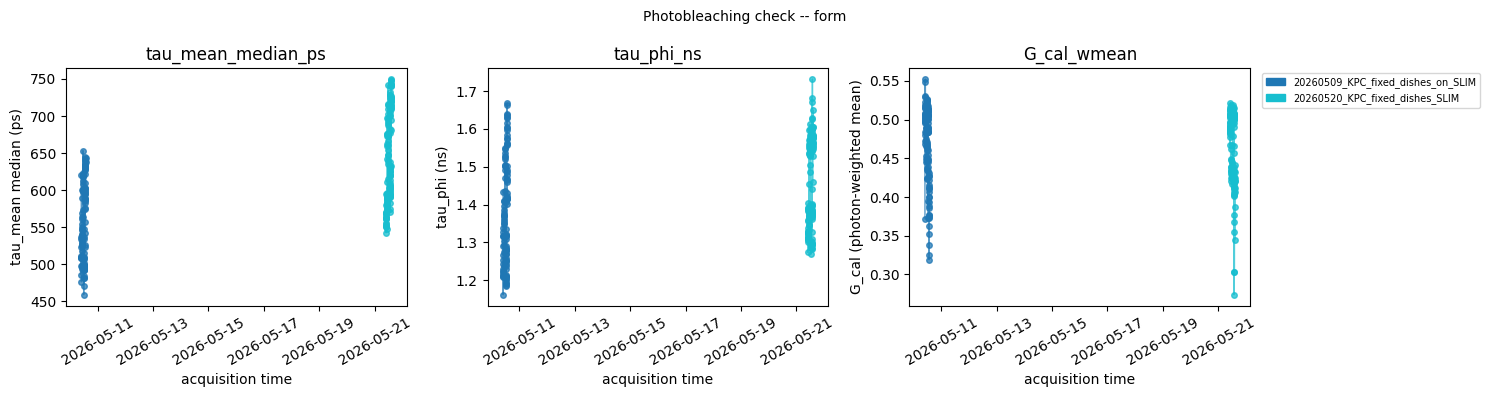

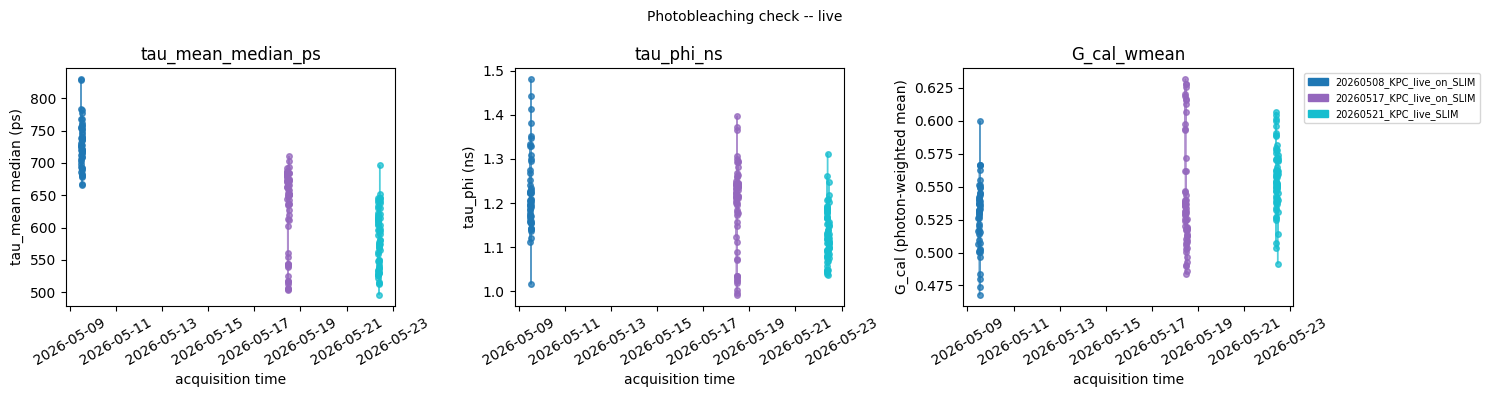

In [8]:
CHECK_METRICS = [m for m in ["tau_mean_median_ps", "tau_phi_ns", "G_cal_wmean"]
                 if m in df.columns and df[m].notna().any()]

if not CHECK_METRICS:
    print("No metrics available for photobleaching check -- run Phases D and E first.")
else:
    for fix_type in fix_present:
        sub = df[df["fixation_type"] == fix_type].copy()
        if sub.empty:
            continue

        sessions  = sorted(sub["session_root"].dropna().unique())
        cmap      = plt.cm.tab10(np.linspace(0, 0.9, max(len(sessions), 1)))
        clr       = {s: cmap[i] for i, s in enumerate(sessions)}

        n_panels = len(CHECK_METRICS)
        fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4),
                                 squeeze=False)

        for ax, metric in zip(axes[0], CHECK_METRICS):
            for sess in sessions:
                pts = (sub[sub["session_root"] == sess]
                       .dropna(subset=["acquisition_time", metric])
                       .sort_values("acquisition_time"))
                if pts.empty:
                    continue
                ax.plot(pts["acquisition_time"], pts[metric], "o-",
                        color=clr[sess], ms=4, lw=1, alpha=0.75, label=sess)
            ax.set_xlabel("acquisition time")
            ax.set_ylabel(METRIC_LABELS.get(metric, metric))
            ax.set_title(metric)
            ax.tick_params(axis="x", labelrotation=30)

        handles = [mpatches.Patch(color=clr[s], label=s) for s in sessions]
        if handles:
            axes[0][-1].legend(handles=handles, fontsize=7,
                               bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.suptitle(f"Photobleaching check -- {fix_type}", fontsize=10)
        plt.tight_layout()
        _savefig(fig, f"fig_batch_check_{fix_type}")
        plt.show()

## Step 21: Violin plots by cell_type x fixation_type x em_filter_nm

Each violin shows the distribution of per-image medians.
Layout: rows = fixation_type, columns = emission channel (457 / 535 nm).
Individual data points overlaid as a strip plot.
Both channel panels share the same y-axis so amplitudes are directly comparable.

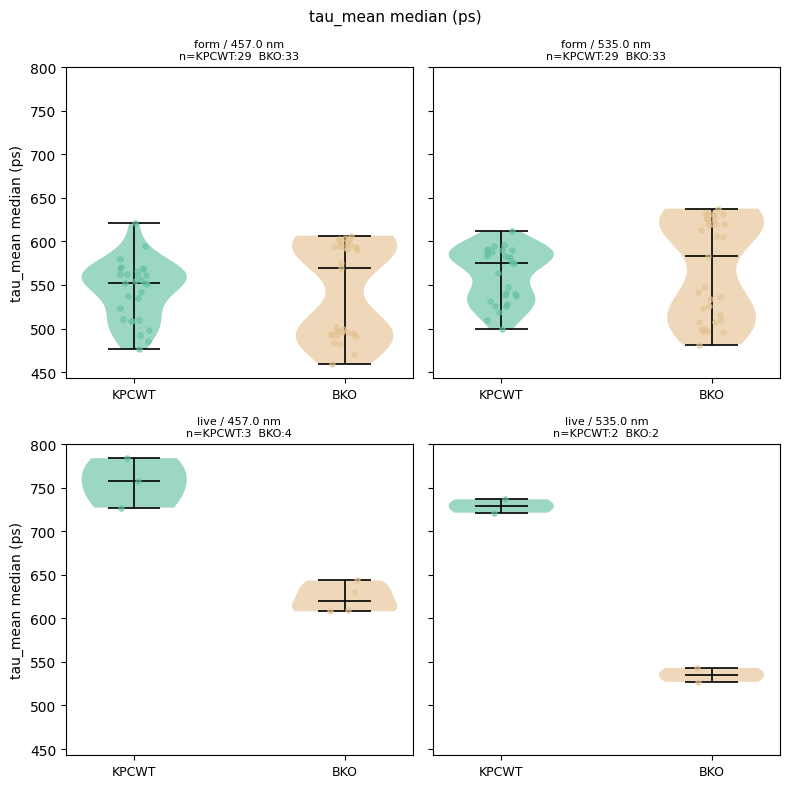

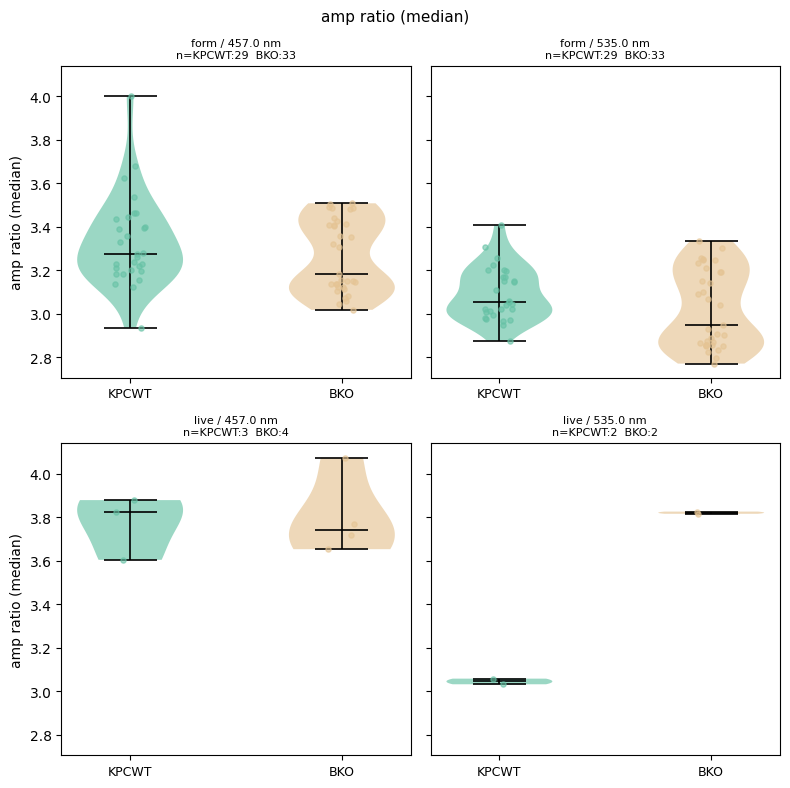

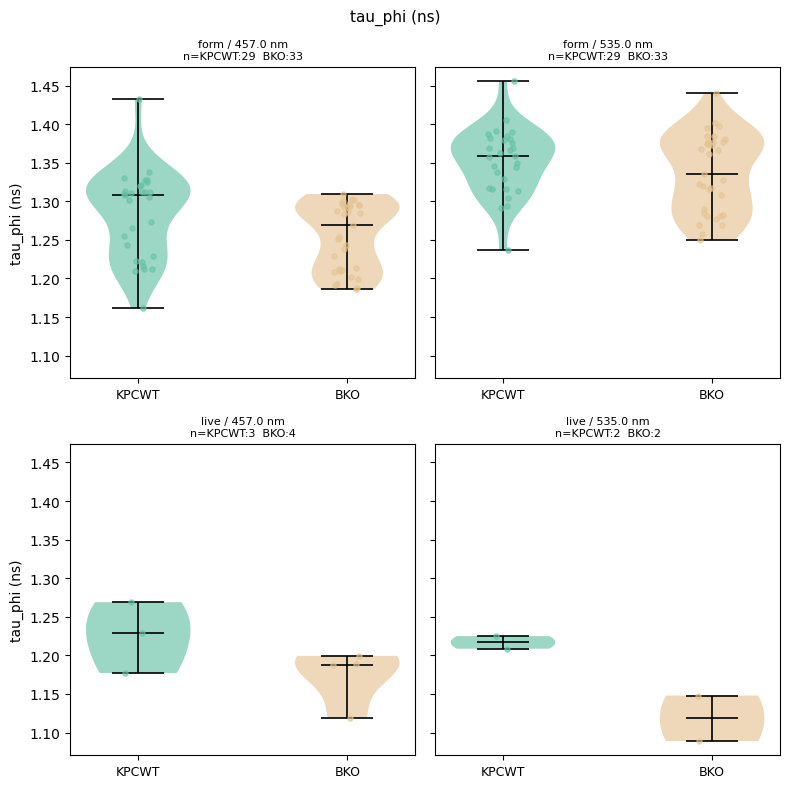

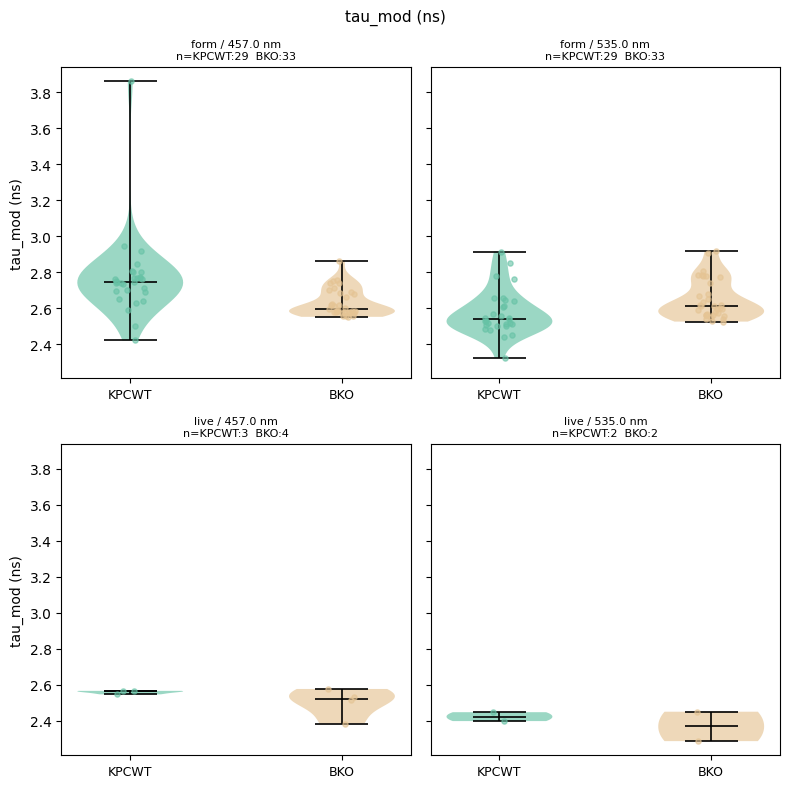

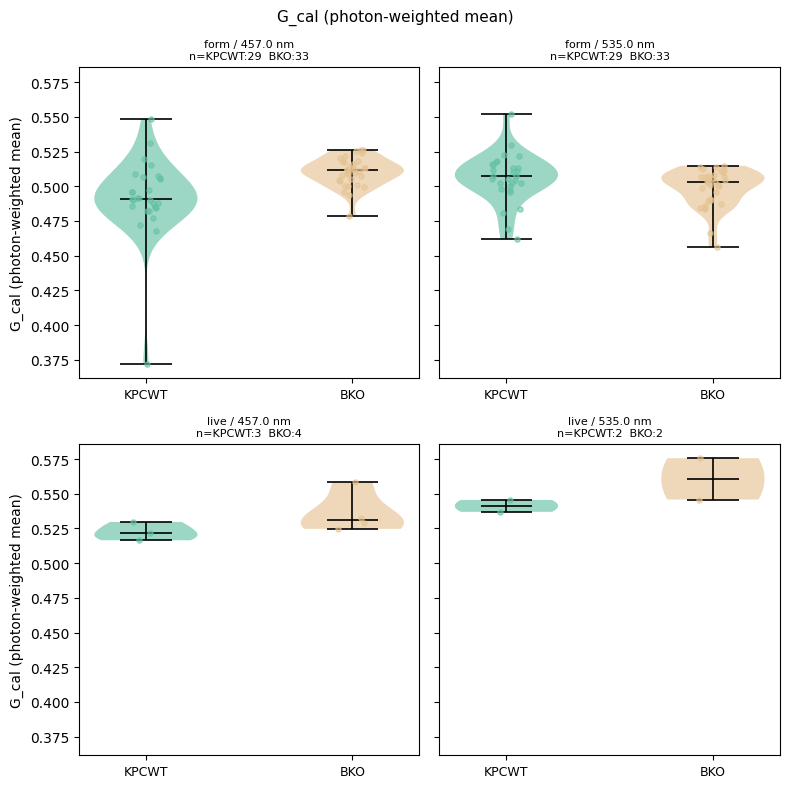

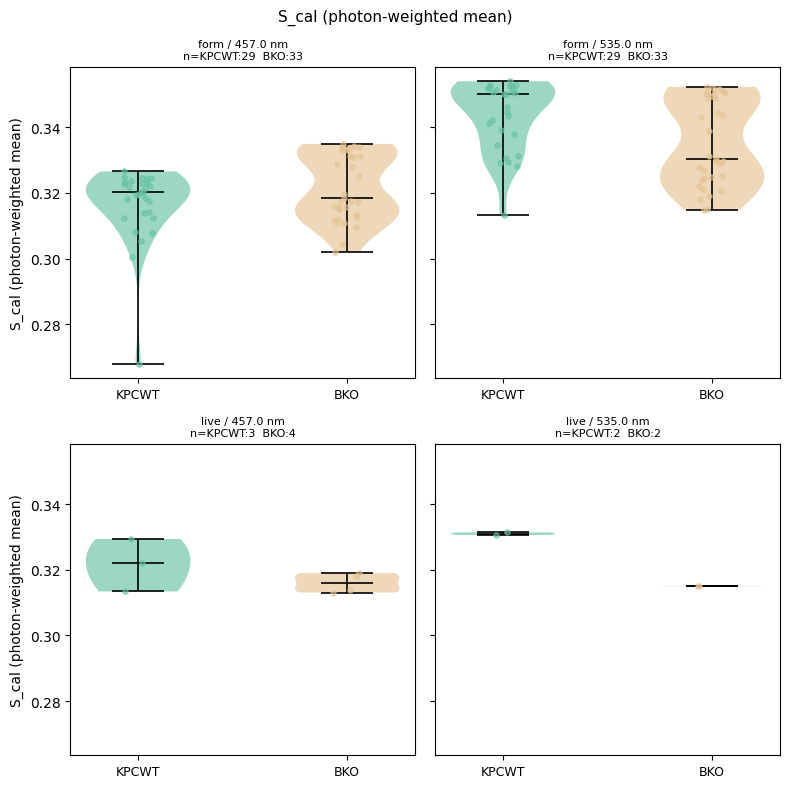

In [9]:
palette  = plt.cm.Set2(np.linspace(0, 0.8, max(len(ct_present), 1)))
ct_color = {ct: palette[i] for i, ct in enumerate(ct_present)}

_channels_21 = sorted(df_analysis["em_filter_nm"].dropna().unique())
_n_rows      = len(fix_present)
_n_cols      = max(len(_channels_21), 1)

for metric in all_metrics:
    label = METRIC_LABELS.get(metric, metric)
    fig, axes = plt.subplots(_n_rows, _n_cols,
                             figsize=(4 * _n_cols, 4 * _n_rows),
                             squeeze=False,
                             sharey=True)

    for ri, fix_type in enumerate(fix_present):
        for ci, ch in enumerate(_channels_21):
            ax = axes[ri][ci]
            sub = (df_analysis[(df_analysis["fixation_type"] == fix_type) &
                               (df_analysis["em_filter_nm"]  == ch) &
                               df_analysis["cell_type"].isin(ct_present)]
                   .dropna(subset=[metric]))

            # Require >= 2 non-NaN values per group: violinplot KDE fails with n < 2.
            cts_here = [ct for ct in ct_present
                        if (sub["cell_type"] == ct).sum() >= 2]
            groups   = [sub[sub["cell_type"] == ct][metric].values for ct in cts_here]
            colors   = [ct_color[ct] for ct in cts_here]

            if not groups:
                ax.set_title(f"{fix_type} / {ch} nm\n(no data)", fontsize=8)
                continue

            parts = ax.violinplot(groups, positions=range(len(groups)),
                                  showmedians=True, showextrema=True)
            for pc, col in zip(parts["bodies"], colors):
                pc.set_facecolor(col)
                pc.set_alpha(0.65)
            for key in ("cmedians", "cbars", "cmins", "cmaxes"):
                if key in parts:
                    parts[key].set_color("k")
                    parts[key].set_linewidth(1.2)

            rng = np.random.default_rng(seed=0)
            for j, (grp, col) in enumerate(zip(groups, colors)):
                jitter = rng.uniform(-0.07, 0.07, len(grp))
                ax.scatter(j + jitter, grp, s=14, color=col, alpha=0.6, zorder=3)

            ax.set_xticks(range(len(cts_here)))
            ax.set_xticklabels(cts_here, fontsize=9)
            if ci == 0:
                ax.set_ylabel(label)
            n_str = "  ".join(f"{ct}:{(sub['cell_type']==ct).sum()}"
                              for ct in cts_here)
            ax.set_title(f"{fix_type} / {ch} nm\nn={n_str}", fontsize=8)

    fig.suptitle(label, fontsize=11)
    plt.tight_layout()
    _savefig(fig, f"fig_violin_{metric}")
    plt.show()

In [10]:
# -- Step 21b: Direction check (text) ----------------------------------------
# Prints the median per group for every violin so the direction of any
# difference is unambiguous regardless of color-blind or scaling issues.

print("=" * 72)
print("STEP 21 DIRECTION CHECK  (median per group, analysis dataset)")
print("=" * 72)
_chans_21b = sorted(df_analysis["em_filter_nm"].dropna().unique())
for _m21 in all_metrics:
    _lbl21 = METRIC_LABELS.get(_m21, _m21)
    _any21  = False
    _lines21 = []
    for _ft21 in fix_present:
        for _ch21 in _chans_21b:
            _meds21 = {}
            for _ct21 in ct_present:
                _v21 = df_analysis[
                    (df_analysis["fixation_type"] == _ft21) &
                    (df_analysis["em_filter_nm"]  == _ch21) &
                    (df_analysis["cell_type"]     == _ct21)
                ][_m21].dropna()
                if len(_v21) >= 2:
                    _meds21[_ct21] = float(_v21.median())
                    _any21 = True
            if _meds21:
                _s21 = sorted(_meds21.items(), key=lambda kv: -kv[1])
                _dir21 = " > ".join(f"{k}({v:.1f})" for k, v in _s21)
                _lines21.append(f"  {_ft21:6s} / {_ch21} nm : {_dir21}")
    if _any21:
        print(f"\n{_lbl21}  [{_m21}]")
        for _ln in _lines21:
            print(_ln)
print("=" * 72)

STEP 21 DIRECTION CHECK  (median per group, analysis dataset)

tau_mean median (ps)  [tau_mean_median_ps]
  form   / 457.0 nm : BKO(570.0) > KPCWT(552.1)
  form   / 535.0 nm : BKO(583.2) > KPCWT(574.9)
  live   / 457.0 nm : KPCWT(757.6) > BKO(620.2)
  live   / 535.0 nm : KPCWT(728.9) > BKO(535.1)

amp ratio (median)  [amp_ratio_median]
  form   / 457.0 nm : KPCWT(3.3) > BKO(3.2)
  form   / 535.0 nm : KPCWT(3.1) > BKO(2.9)
  live   / 457.0 nm : KPCWT(3.8) > BKO(3.7)
  live   / 535.0 nm : BKO(3.8) > KPCWT(3.0)

tau_phi (ns)  [tau_phi_ns]
  form   / 457.0 nm : KPCWT(1.3) > BKO(1.3)
  form   / 535.0 nm : KPCWT(1.4) > BKO(1.3)
  live   / 457.0 nm : KPCWT(1.2) > BKO(1.2)
  live   / 535.0 nm : KPCWT(1.2) > BKO(1.1)

tau_mod (ns)  [tau_mod_ns]
  form   / 457.0 nm : KPCWT(2.7) > BKO(2.6)
  form   / 535.0 nm : BKO(2.6) > KPCWT(2.5)
  live   / 457.0 nm : KPCWT(2.6) > BKO(2.5)
  live   / 535.0 nm : KPCWT(2.4) > BKO(2.4)

G_cal (photon-weighted mean)  [G_cal_wmean]
  form   / 457.0 nm : BKO(0.5) > 

## Step 21c: Per-session, per-channel violin plots

One figure per (metric, fixation_type, channel).
Columns = individual imaging sessions (date extracted from session_root).
Within each column: violins per cell_type, shared y-axis across sessions.

Purpose: check whether the direction of BKO vs KPCWT is consistent within
each session.  If two sessions disagree (e.g. 20260509 and 20260520 for
tau_mean at 457 nm), the aggregate Step 21 violin is unreliable for that
metric/channel, and only metrics that agree across sessions are defensible.

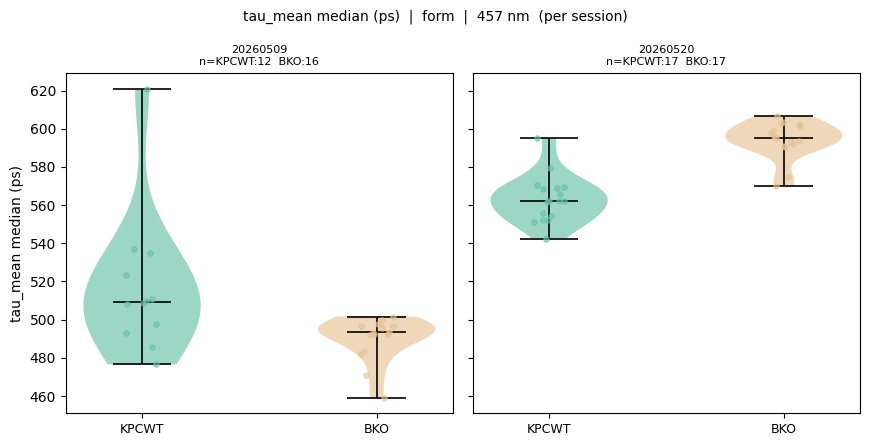

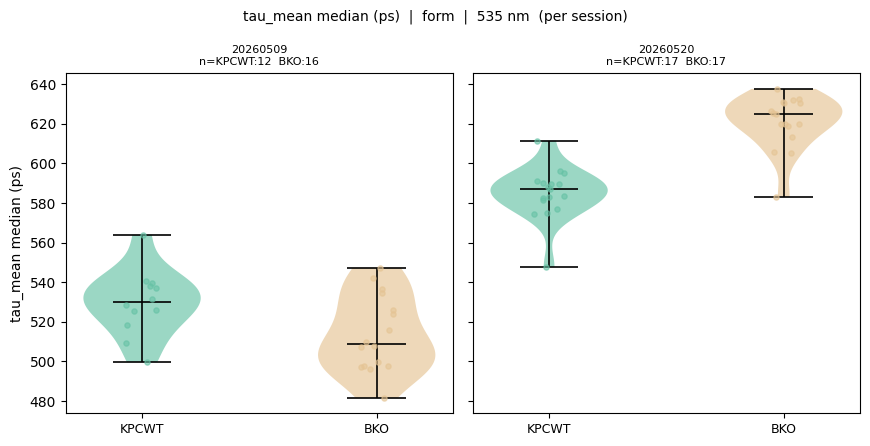

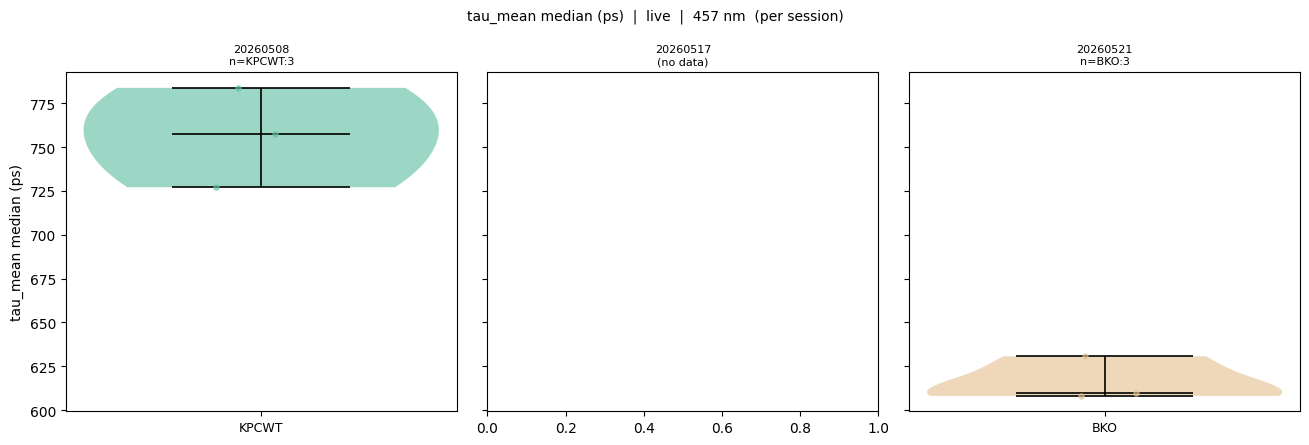

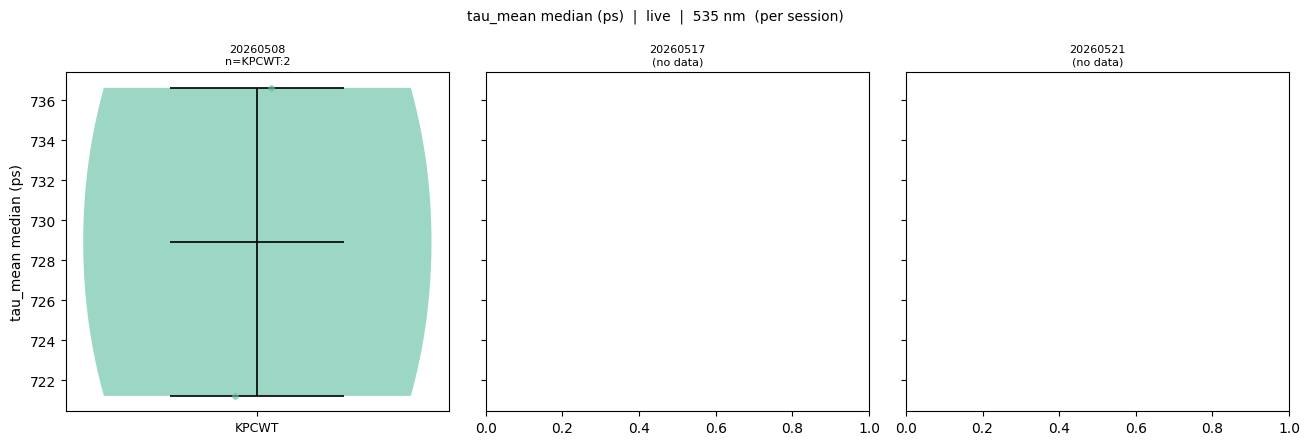

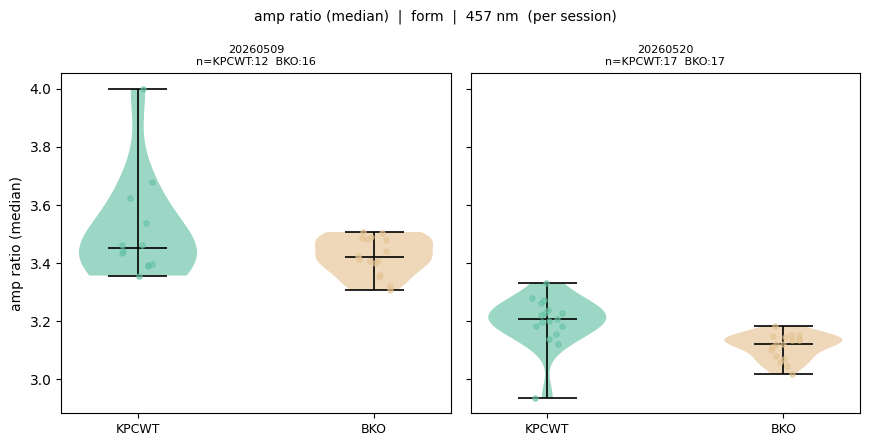

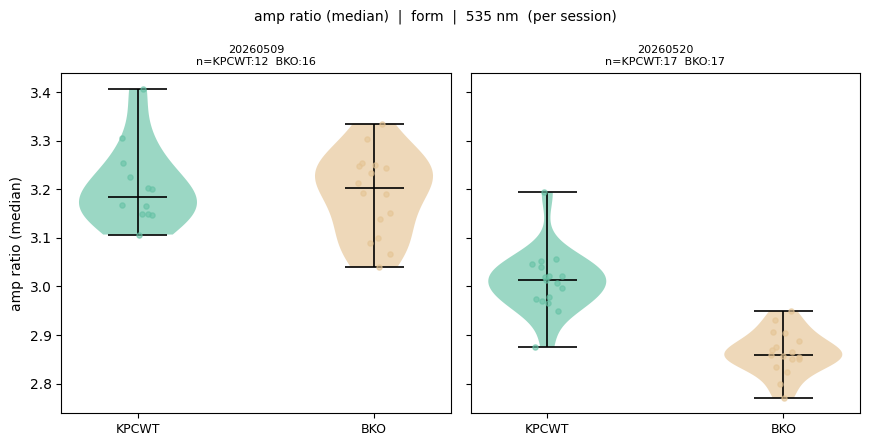

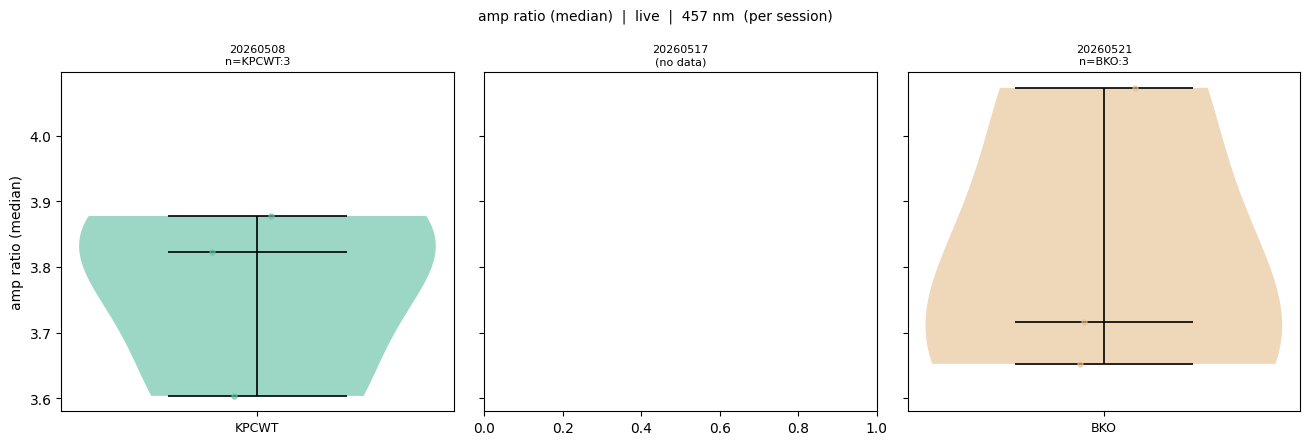

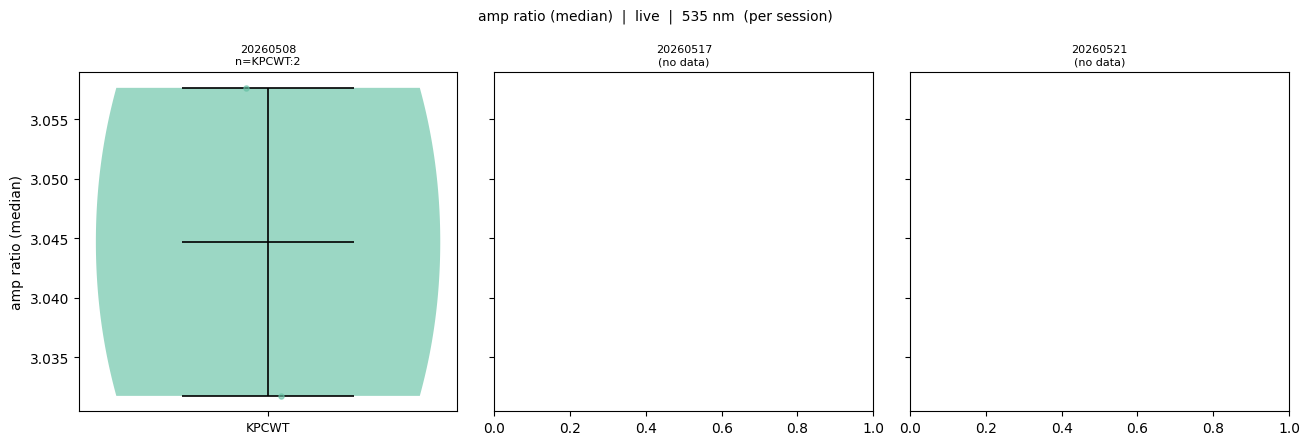

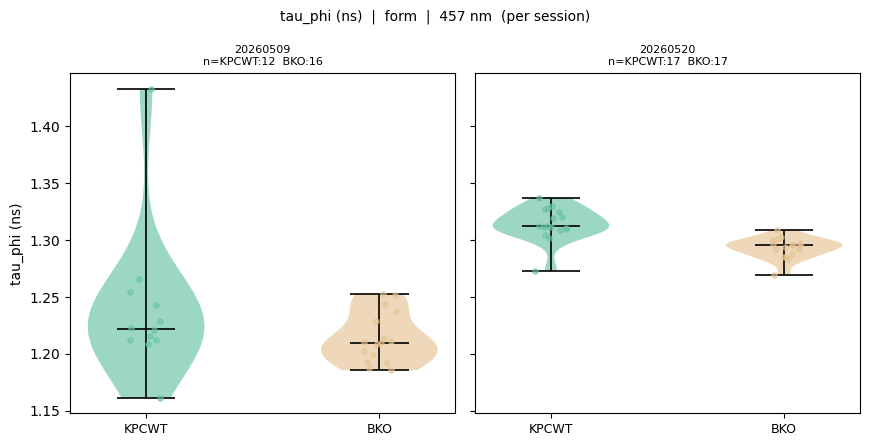

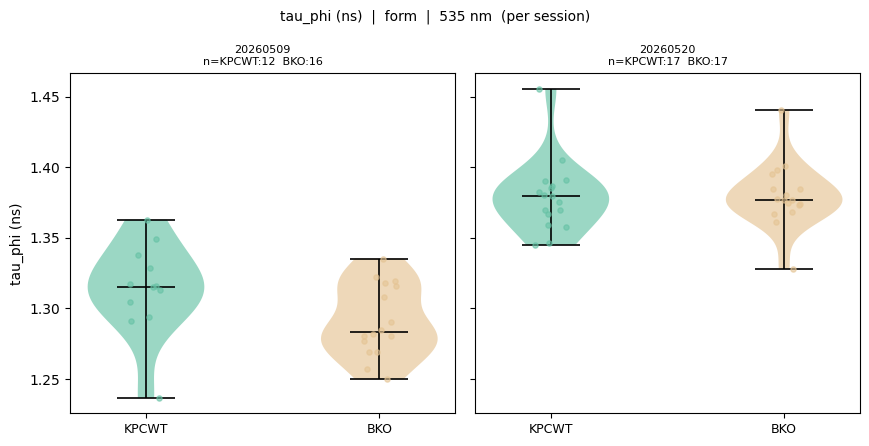

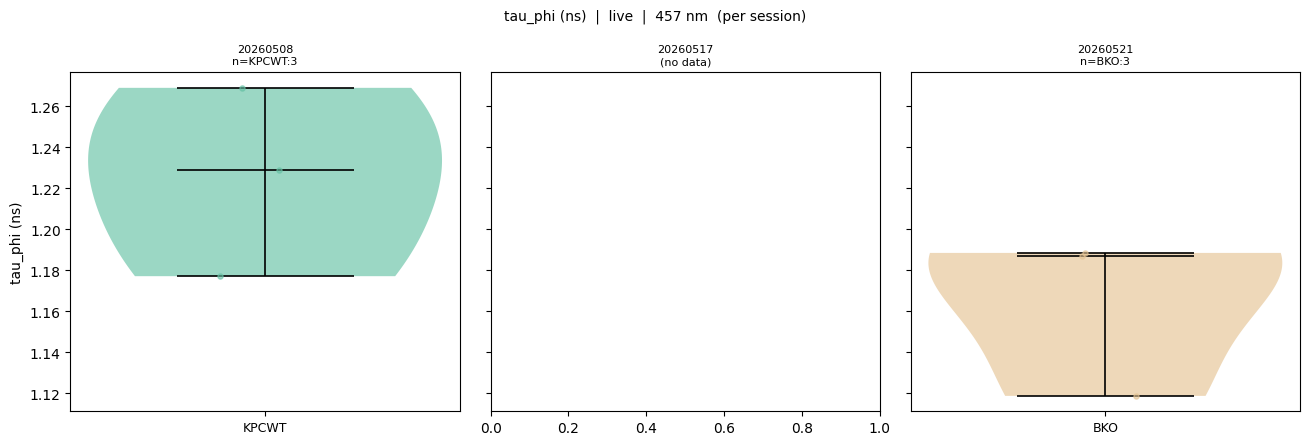

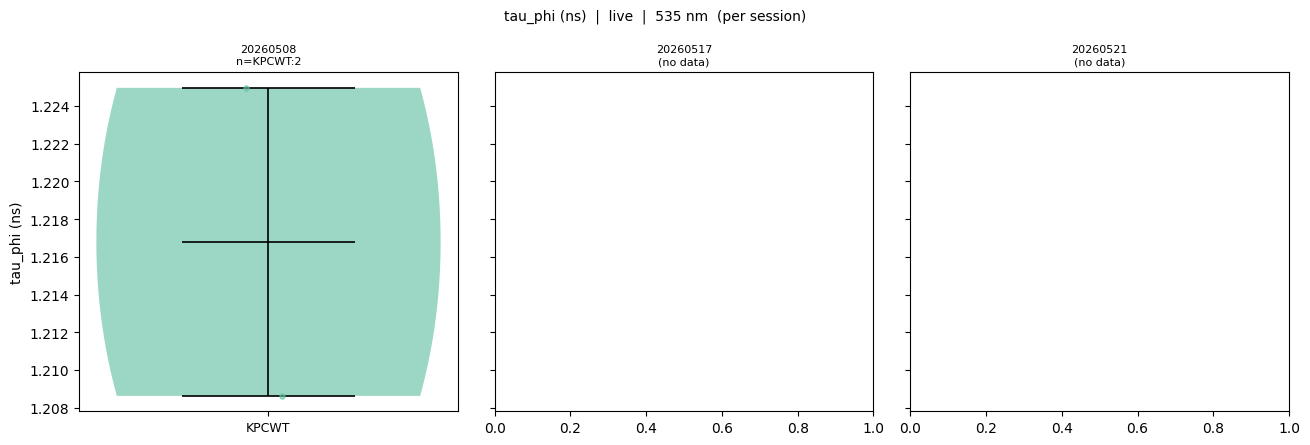

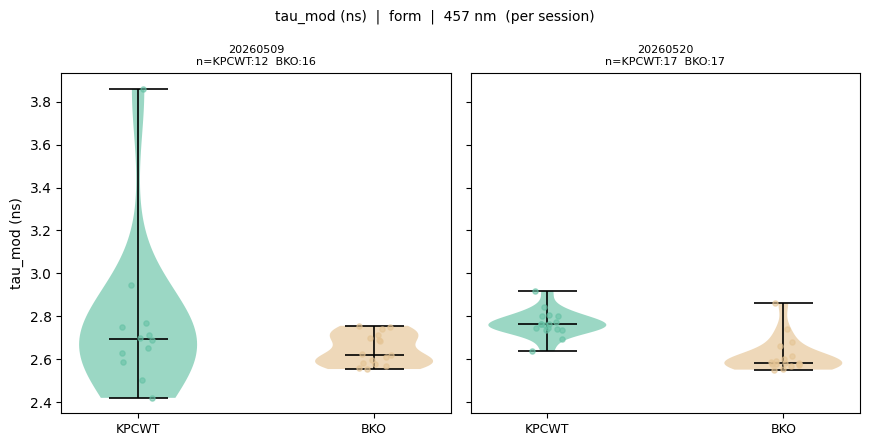

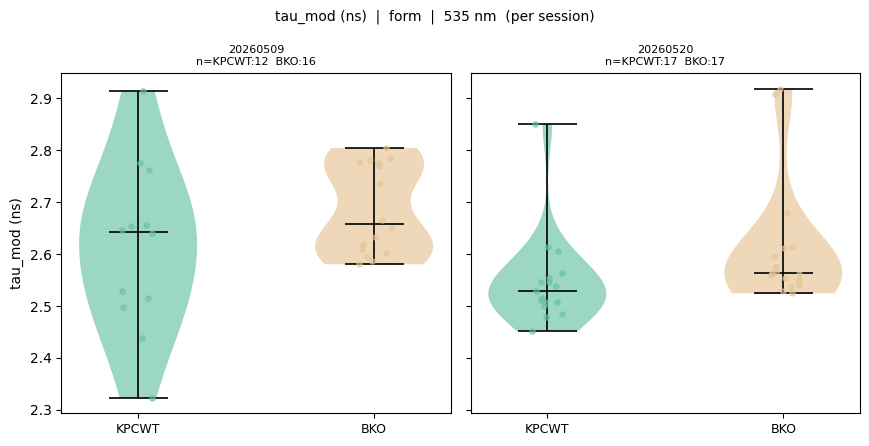

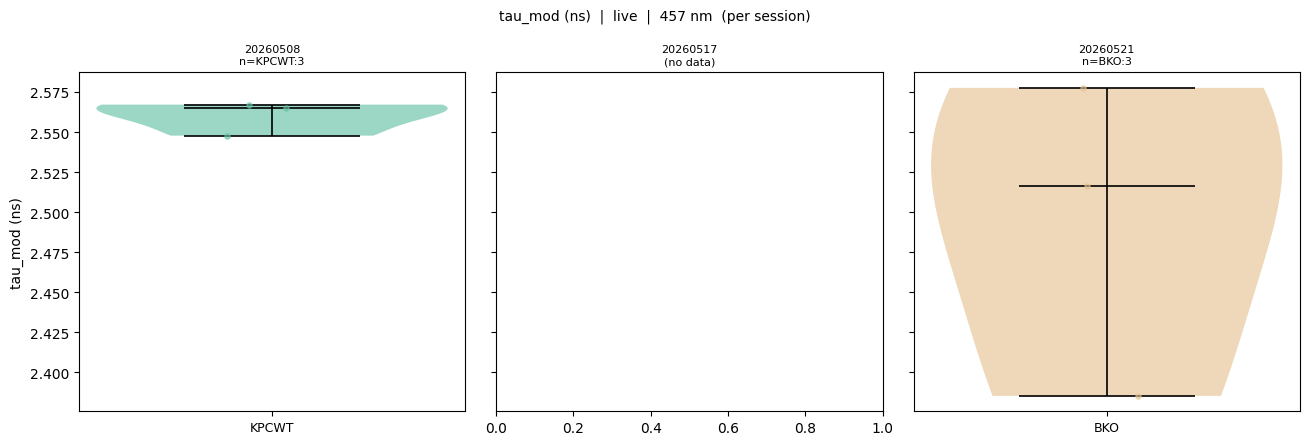

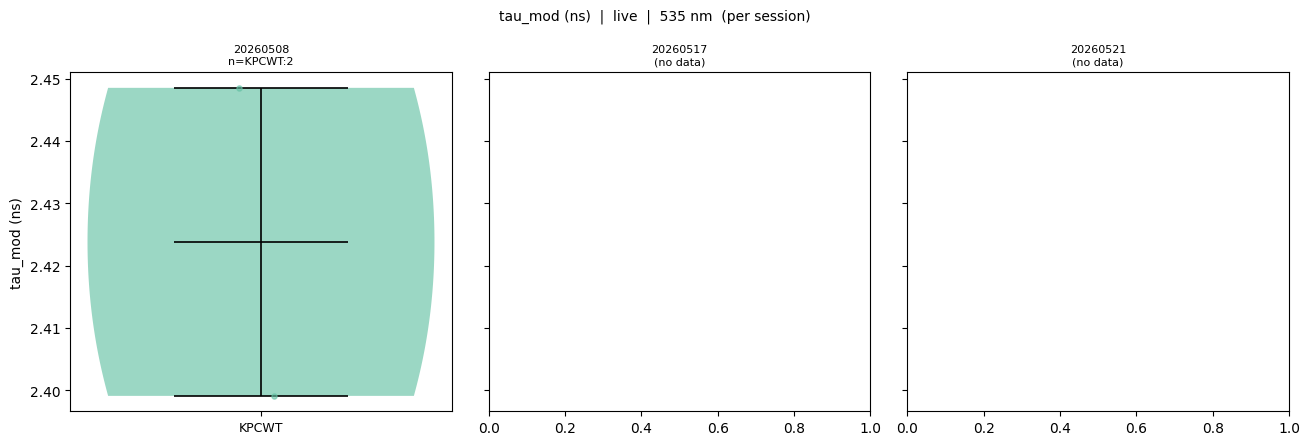

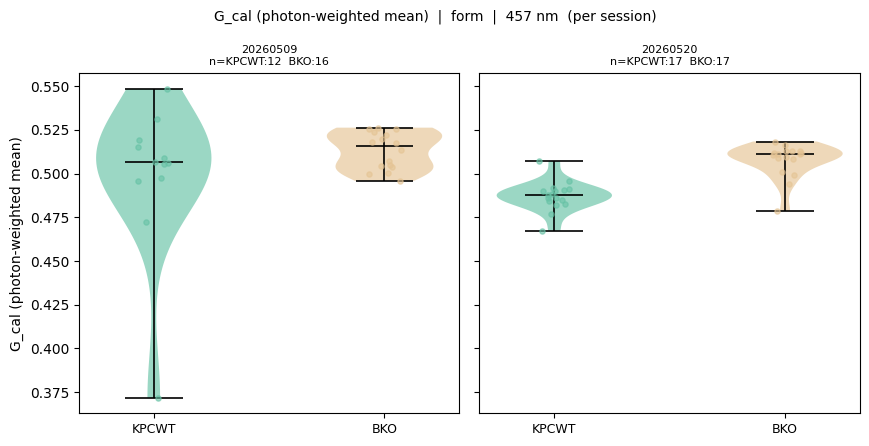

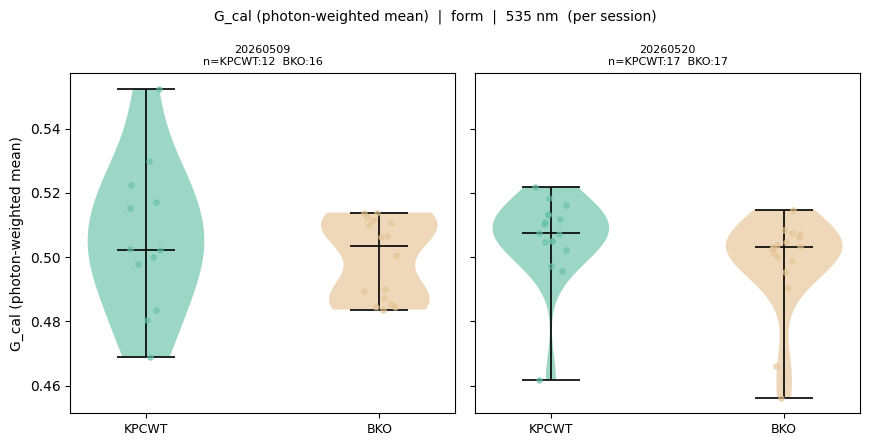

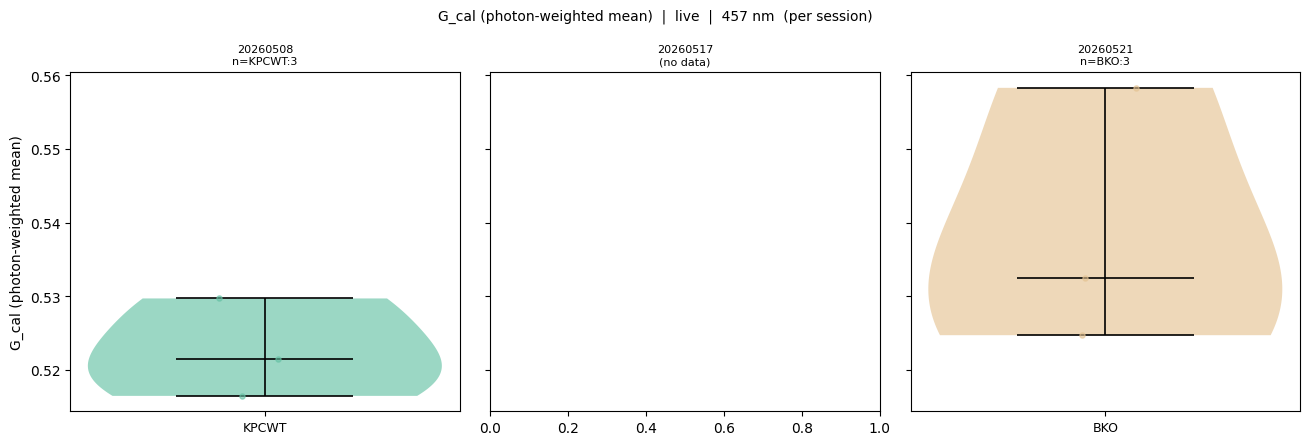

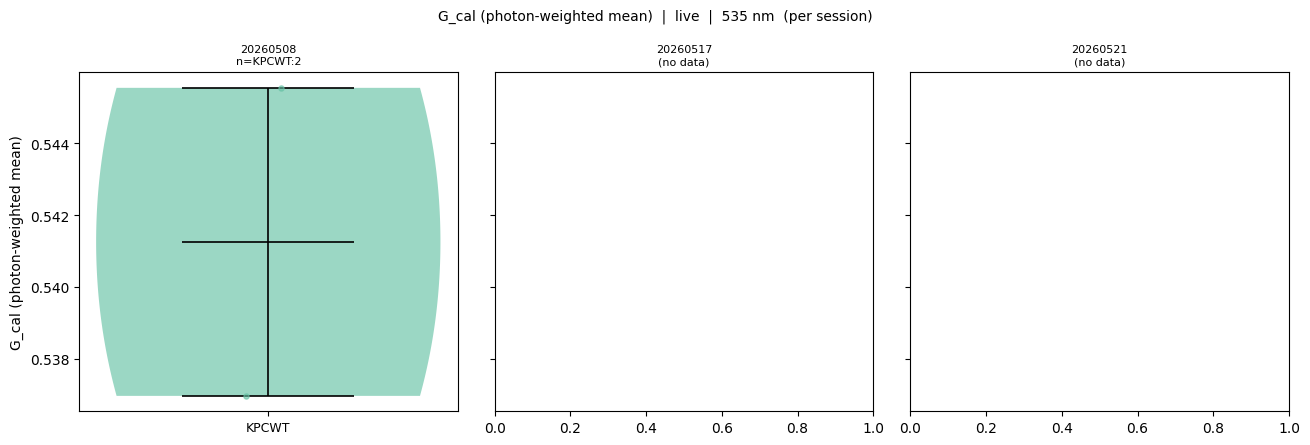

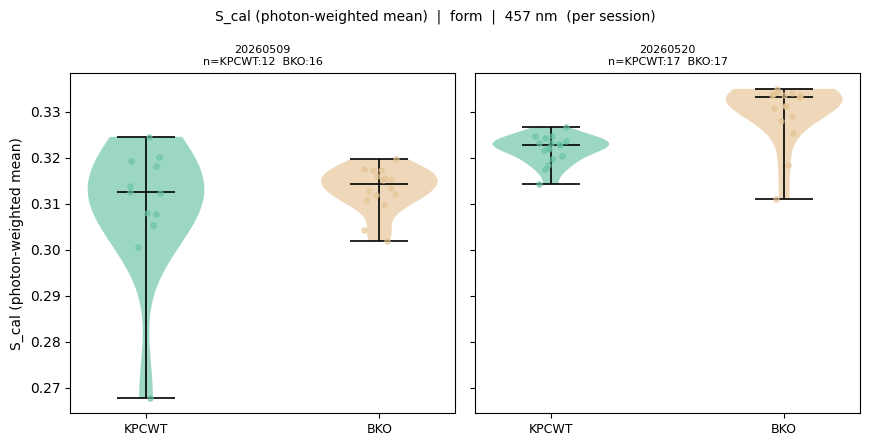

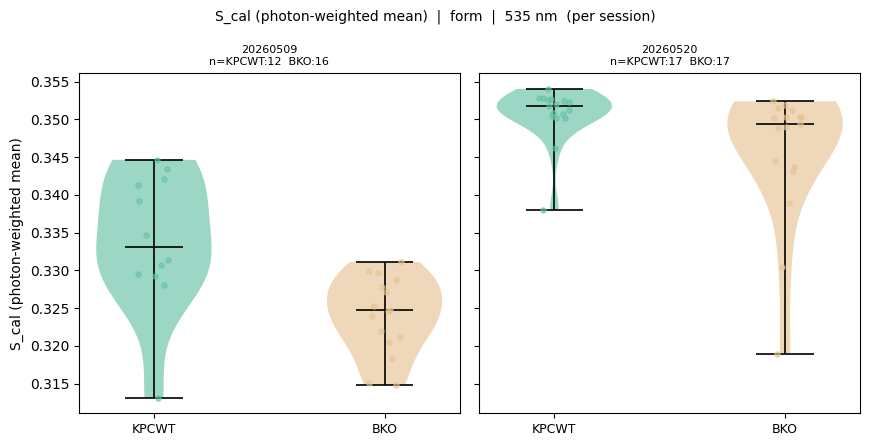

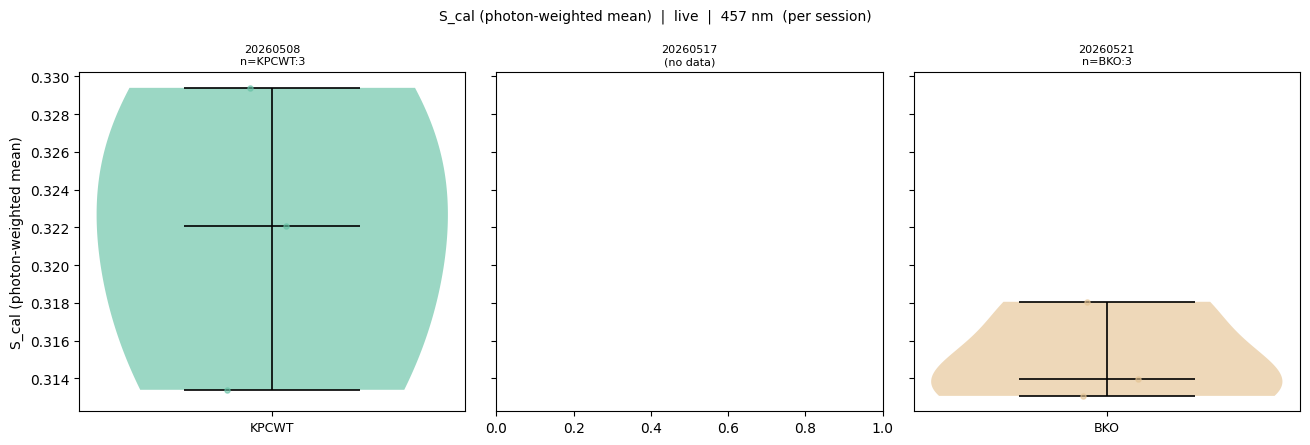

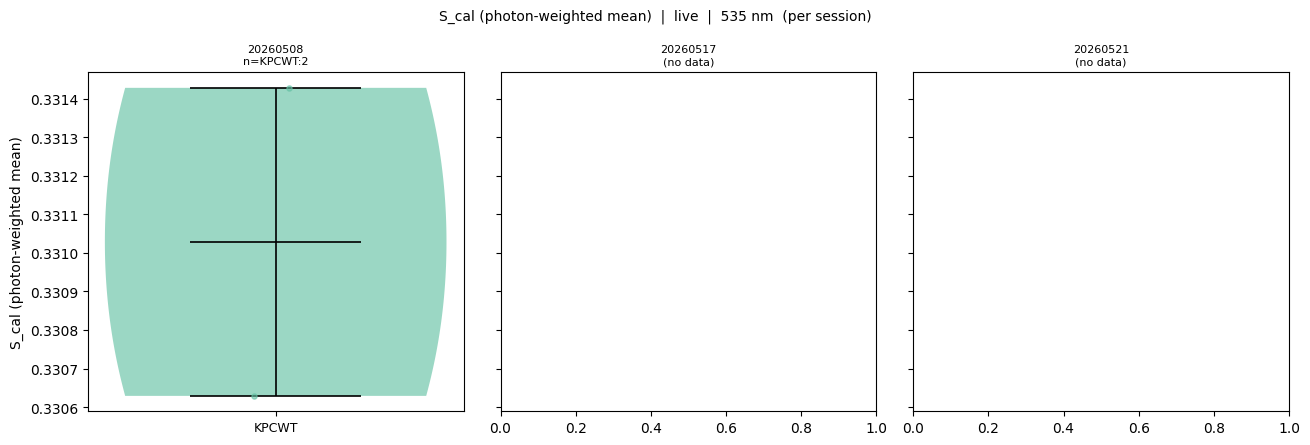

In [11]:
for _m21c in all_metrics:
    _lbl21c = METRIC_LABELS.get(_m21c, _m21c)
    for _ft21c in fix_present:
        for _ch21c in sorted(df_analysis["em_filter_nm"].dropna().unique()):
            _sub_fc = (df_analysis[
                (df_analysis["fixation_type"] == _ft21c) &
                (df_analysis["em_filter_nm"]  == _ch21c) &
                df_analysis["cell_type"].isin(ct_present)
            ].dropna(subset=[_m21c]))
            if _sub_fc.empty:
                continue

            _sessions_fc = sorted(_sub_fc["session_root"].dropna().unique())
            if not _sessions_fc:
                continue

            _n_sess21c = len(_sessions_fc)
            _fig21c, _axes21c = plt.subplots(
                1, _n_sess21c,
                figsize=(max(2.8, 2.2 * len(ct_present)) * _n_sess21c, 4.5),
                squeeze=False,
                sharey=True,
            )

            for _si, _sess in enumerate(_sessions_fc):
                _ax = _axes21c[0][_si]
                _sub_s = _sub_fc[_sub_fc["session_root"] == _sess]
                _cts_s = [ct for ct in ct_present
                          if (_sub_s["cell_type"] == ct).sum() >= 2]
                _grps_s = [_sub_s[_sub_s["cell_type"] == ct][_m21c].values
                           for ct in _cts_s]
                _cols_s = [ct_color[ct] for ct in _cts_s]

                if not _grps_s:
                    _ax.set_title(f"{_sess.split('_')[0]}\n(no data)", fontsize=8)
                    continue

                _parts21c = _ax.violinplot(_grps_s, positions=range(len(_grps_s)),
                                           showmedians=True, showextrema=True)
                for _pc, _col in zip(_parts21c["bodies"], _cols_s):
                    _pc.set_facecolor(_col)
                    _pc.set_alpha(0.65)
                for _key in ("cmedians", "cbars", "cmins", "cmaxes"):
                    if _key in _parts21c:
                        _parts21c[_key].set_color("k")
                        _parts21c[_key].set_linewidth(1.2)

                _rng21c = np.random.default_rng(seed=_si)
                for _j, (_grp, _col) in enumerate(zip(_grps_s, _cols_s)):
                    _jit = _rng21c.uniform(-0.07, 0.07, len(_grp))
                    _ax.scatter(_j + _jit, _grp, s=14,
                                color=_col, alpha=0.6, zorder=3)

                _ax.set_xticks(range(len(_cts_s)))
                _ax.set_xticklabels(_cts_s, fontsize=9)
                if _si == 0:
                    _ax.set_ylabel(_lbl21c)
                _n_s = "  ".join(f"{ct}:{(_sub_s['cell_type']==ct).sum()}"
                                 for ct in _cts_s)
                _ax.set_title(f"{_sess.split('_')[0]}\nn={_n_s}", fontsize=8)

            _fig21c.suptitle(
                f"{_lbl21c}  |  {_ft21c}  |  {int(_ch21c)} nm  (per session)",
                fontsize=10,
            )
            plt.tight_layout()
            _savefig(_fig21c,
                     f"fig_violin_sess_{_ft21c}_{int(_ch21c)}_{_m21c}")
            plt.show()

## Step 22: Pairwise statistical tests

For each (fixation_type, metric): Mann-Whitney U on all pairs of cell_types
with >= MIN_N images. Benjamini-Hochberg FDR applied across all pairs
within each (fixation_type, metric) block.

Effect size: rank-biserial r = 2U/(n1*n2) - 1.
Interpretation: |r| < 0.3 small, 0.3-0.5 medium, > 0.5 large.
Sign: positive r means group_a tends to be larger than group_b.

In [12]:
# -- benjamini_hochberg + rank_biserial_r migrated to src/metrics.py --------
import sys as _sys_phaseF
_sys_phaseF.path.insert(0, str(Path("..").resolve()))
from src.metrics import benjamini_hochberg, rank_biserial_r


stat_rows = []

for fix_type in fix_present:
    sub  = df_analysis[df_analysis["fixation_type"] == fix_type]
    # Include a cell type if it has >= MIN_N total rows in df_analysis for this
    # fixation_type.  Per-metric NaN filtering is handled inside the metric loop
    # by the `if len(x) < MIN_N or len(y) < MIN_N: continue` guard.
    cts  = [ct for ct in ct_present
            if len(sub[sub["cell_type"] == ct]) >= MIN_N]
    if len(cts) < 2:
        continue
    pairs = list(itertools.combinations(cts, 2))

    for metric in all_metrics:
        p_raw     = []
        pair_data = []
        for ct_a, ct_b in pairs:
            x = sub[sub["cell_type"] == ct_a][metric].dropna().values
            y = sub[sub["cell_type"] == ct_b][metric].dropna().values
            if len(x) < MIN_N or len(y) < MIN_N:
                continue
            U_res = stats.mannwhitneyu(x, y, alternative="two-sided")
            p_raw.append(U_res.pvalue)
            pair_data.append({
                "fixation_type": fix_type,
                "metric":        metric,
                "group_a":       ct_a,
                "group_b":       ct_b,
                "n_a":           len(x),
                "n_b":           len(y),
                "median_a":      float(np.median(x)),
                "median_b":      float(np.median(y)),
                "U":             float(U_res.statistic),
                "p_raw":         float(U_res.pvalue),
                "r":             rank_biserial_r(x, y),
            })

        if not pair_data:
            continue
        q_vals = benjamini_hochberg(p_raw)
        for row, q in zip(pair_data, q_vals):
            row["q_bh"] = float(q)
            row["sig"]  = bool(q < FDR_ALPHA)
            stat_rows.append(row)

stat_df = pd.DataFrame(stat_rows)
print(f"Statistical tests: {len(stat_df)} comparisons")

if not stat_df.empty:
    sig = stat_df[stat_df["sig"]]
    print(f"Significant after BH-FDR (q < {FDR_ALPHA}): {len(sig)}")
    if not sig.empty:
        print(sig[["fixation_type", "metric", "group_a", "group_b",
                   "median_a", "median_b", "r", "q_bh"]]
              .round(4).to_string(index=False))

stat_df.to_csv(results_dir / "stat_tests.csv", index=False)
print(f"\nSaved: {results_dir / 'stat_tests.csv'}")

Statistical tests: 12 comparisons
Significant after BH-FDR (q < 0.05): 3
fixation_type             metric group_a group_b  median_a  median_b      r   q_bh
         form         tau_phi_ns   KPCWT     BKO    1.3184    1.2932 0.2529 0.0155
         live tau_mean_median_ps   KPCWT     BKO  736.6209  608.8929 1.0000 0.0043
         live         tau_phi_ns   KPCWT     BKO    1.2250    1.1675 0.8000 0.0303

Saved: ..\results\stat_tests.csv


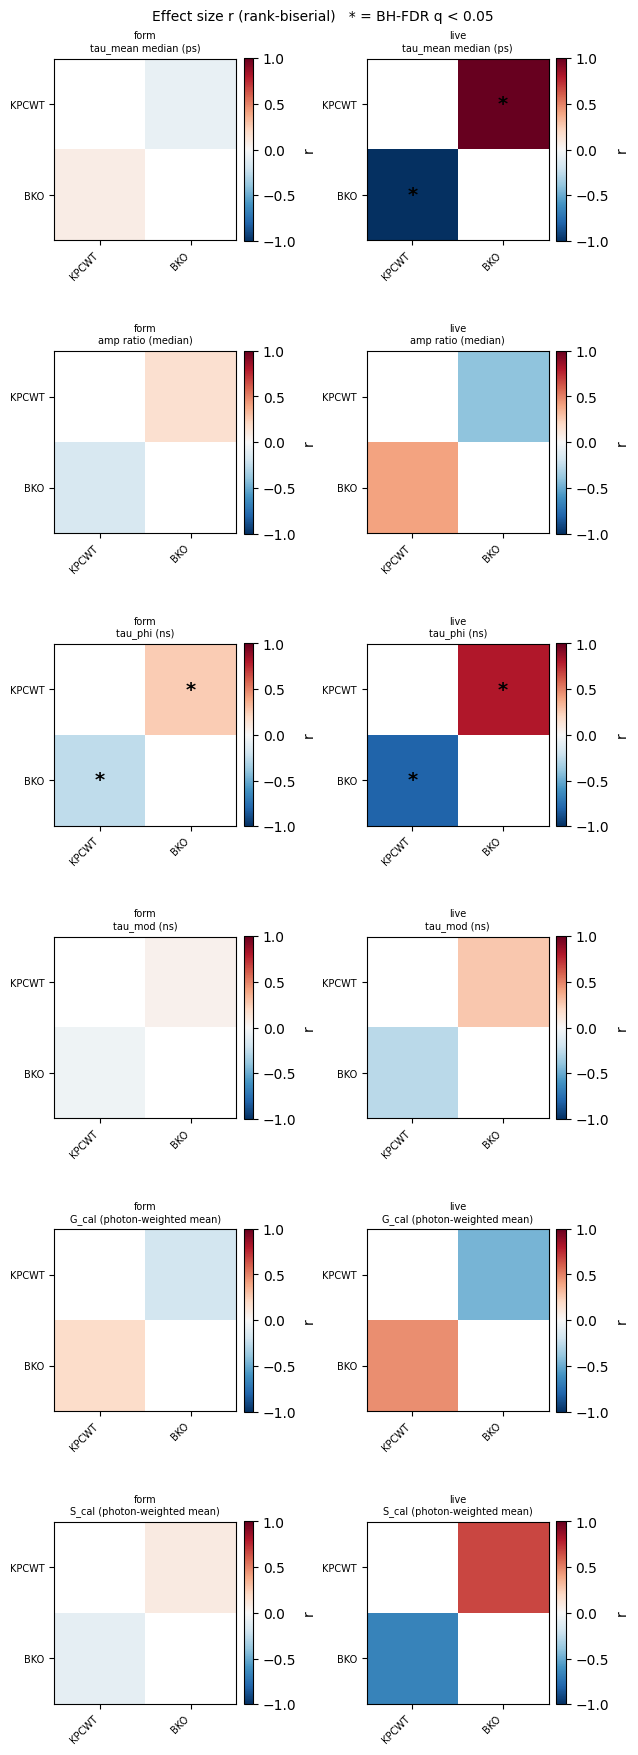

In [13]:
# -- Effect size heatmap (r) with significance markers --------------------
if not stat_df.empty:
    n_met = len(all_metrics)
    n_fix = len(fix_present)
    fig, axes = plt.subplots(n_met, n_fix,
                             figsize=(3.2 * n_fix, 3.0 * n_met),
                             squeeze=False)

    for r_idx, metric in enumerate(all_metrics):
        for c_idx, fix_type in enumerate(fix_present):
            ax  = axes[r_idx][c_idx]
            sub_stat = stat_df[
                (stat_df["metric"] == metric) &
                (stat_df["fixation_type"] == fix_type)
            ]
            cts = [ct for ct in ct_present
                   if len(df_analysis[(df_analysis["fixation_type"] == fix_type) &
                                      (df_analysis["cell_type"] == ct)]) >= MIN_N]
            n   = len(cts)
            if n < 2:
                ax.set_visible(False)
                continue

            ct_idx = {ct: i for i, ct in enumerate(cts)}
            mat_r  = np.full((n, n), np.nan)
            mat_q  = np.full((n, n), np.nan)
            for _, row in sub_stat.iterrows():
                i = ct_idx.get(row["group_a"])
                j = ct_idx.get(row["group_b"])
                if i is None or j is None:
                    continue
                mat_r[i, j] =  row["r"]
                mat_r[j, i] = -row["r"]
                mat_q[i, j] = mat_q[j, i] = row["q_bh"]

            im = ax.imshow(mat_r, cmap="RdBu_r", vmin=-1, vmax=1)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="r")
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(cts, fontsize=7, rotation=45, ha="right")
            ax.set_yticklabels(cts, fontsize=7)
            for i2 in range(n):
                for j2 in range(n):
                    if np.isfinite(mat_q[i2, j2]) and mat_q[i2, j2] < FDR_ALPHA:
                        ax.text(j2, i2, "*", ha="center", va="center",
                                fontsize=14, color="k", fontweight="bold")
            ax.set_title(f"{fix_type}\n{METRIC_LABELS.get(metric, metric)}",
                         fontsize=7)

    plt.suptitle("Effect size r (rank-biserial)   * = BH-FDR q < "
                 + str(FDR_ALPHA), fontsize=10)
    plt.tight_layout()
    _savefig(fig, "fig_effect_size_heatmap")
    plt.show()

## Step 23: Phasor vs fit cross-validation

Scatter plot of phasor-derived lifetime (tau_phi, tau_mod) against
amplitude-weighted tau_mean from fitting. Both are converted to ns.
High Spearman r -> both methods track the same signal.
A systematic offset indicates calibration bias in one method.

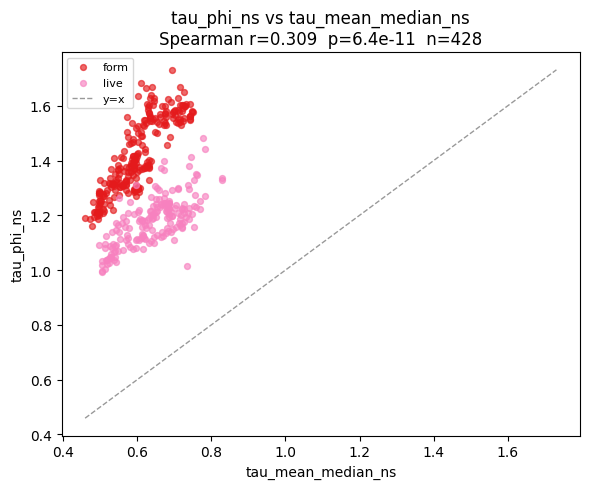

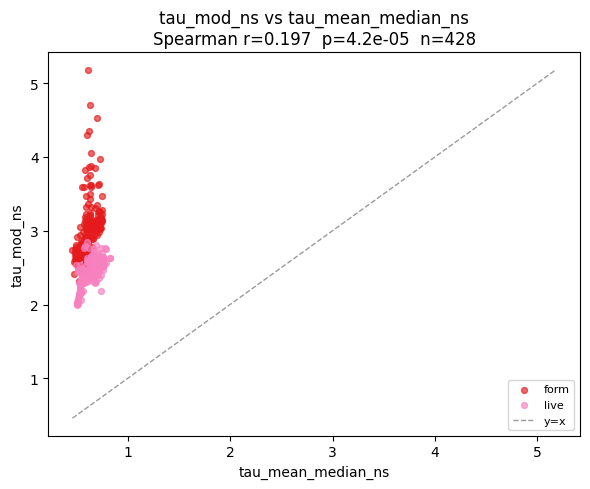

In [14]:
xval_pairs = [
    ("tau_phi_ns", "tau_mean_median_ps"),
    ("tau_mod_ns", "tau_mean_median_ps"),
]

palette_fix = plt.cm.Set1(np.linspace(0, 0.8, max(len(fix_present), 1)))
fix_color   = {ft: palette_fix[i] for i, ft in enumerate(fix_present)}

for y_col, x_col in xval_pairs:
    if y_col not in df.columns or x_col not in df.columns:
        continue
    sub = df.dropna(subset=[x_col, y_col]).copy()
    if sub.empty:
        print(f"No data for {y_col} vs {x_col}")
        continue

    # Convert fit metric to ns if exported in ps
    x_vals  = sub[x_col] / 1000.0 if x_col.endswith("_ps") else sub[x_col]
    x_label = x_col.replace("_ps", "_ns")

    fig, ax = plt.subplots(figsize=(6, 5))
    for ft in fix_present:
        m = sub["fixation_type"] == ft
        if not m.any():
            continue
        ax.scatter(x_vals[m], sub.loc[m, y_col],
                   color=fix_color[ft], alpha=0.65, s=18, label=ft)

    # Unity line over the data range
    lo = float(min(x_vals.min(), sub[y_col].min()))
    hi = float(max(x_vals.max(), sub[y_col].max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.4, label="y=x")

    r_sp, p_sp = stats.spearmanr(x_vals, sub[y_col])
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_label}\n"
                 f"Spearman r={r_sp:.3f}  p={p_sp:.2g}  n={len(sub)}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    _savefig(fig, f"fig_xval_{y_col}_vs_{x_col}")
    plt.show()

## Step 24: Group summary table

Mean +/- SEM across images, stratified by fixation_type x cell_type.

In [15]:
summary_rows = []
for fix_type in fix_present:
    for ct in ct_present:
        sub = df_analysis[(df_analysis["fixation_type"] == fix_type) &
                          (df_analysis["cell_type"] == ct)]
        if sub.empty:
            continue
        rec = {"fixation_type": fix_type, "cell_type": ct, "n_files": len(sub)}
        for metric in all_metrics:
            vals = sub[metric].dropna()
            rec[f"{metric}_n"]    = len(vals)
            rec[f"{metric}_mean"] = float(vals.mean()) if len(vals) > 0 else np.nan
            rec[f"{metric}_sem"]  = float(vals.sem())  if len(vals) > 1 else np.nan
        summary_rows.append(rec)

summary_df = pd.DataFrame(summary_rows)

# Print a readable view: mean (SEM) per metric
if not summary_df.empty:
    print("Group means (SEM in parentheses):\n")
    for metric in all_metrics:
        mn_col  = f"{metric}_mean"
        sem_col = f"{metric}_sem"
        n_col   = f"{metric}_n"
        if mn_col not in summary_df.columns:
            continue
        print(f"  {METRIC_LABELS.get(metric, metric)}")
        for _, row in summary_df.iterrows():
            mn  = row.get(mn_col)
            sem = row.get(sem_col)
            n   = int(row.get(n_col, 0))
            val = f"{mn:.3g} ({sem:.2g})" if pd.notna(mn) and pd.notna(sem) else "n/a"
            print(f"    {row['fixation_type']:6s}  {row['cell_type']:8s}  "
                  f"n={n:3d}   {val}")
        print()

summary_df.to_csv(results_dir / "group_summary.csv", index=False)
print(f"Saved: {results_dir / 'group_summary.csv'}")

Group means (SEM in parentheses):

  tau_mean median (ps)
    form    KPCWT     n= 58   553 (4.4)
    form    BKO       n= 66   556 (6.9)
    live    KPCWT     n=  5   745 (11)
    live    BKO       n=  6   594 (19)

  amp ratio (median)
    form    KPCWT     n= 58   3.21 (0.027)
    form    BKO       n= 66   3.14 (0.026)
    live    KPCWT     n=  5   3.48 (0.18)
    live    BKO       n=  6   3.81 (0.059)

  tau_phi (ns)
    form    KPCWT     n= 58   1.32 (0.008)
    form    BKO       n= 66   1.3 (0.0077)
    live    KPCWT     n=  5   1.22 (0.015)
    live    BKO       n=  6   1.16 (0.018)

  tau_mod (ns)
    form    KPCWT     n= 58   2.67 (0.028)
    form    BKO       n= 66   2.64 (0.012)
    live    KPCWT     n=  5   2.51 (0.034)
    live    BKO       n=  6   2.46 (0.044)

  G_cal (photon-weighted mean)
    form    KPCWT     n= 58   0.499 (0.0033)
    form    BKO       n= 66   0.505 (0.0016)
    live    KPCWT     n=  5   0.53 (0.0052)
    live    BKO       n=  6   0.544 (0.008)

  S_

## Step 25: Per-channel comparison

Violin plots of amplitude ratio and tau_mean faceted by emission channel
(em_filter_nm). Shows whether BKO vs KPCWT differences are consistent
across 457 nm (NADH) and 535 nm (FAD / scatter) channels.

C:\Users\hyeonho\AppData\Local\Temp\ipykernel_10500\139722550.py:97: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


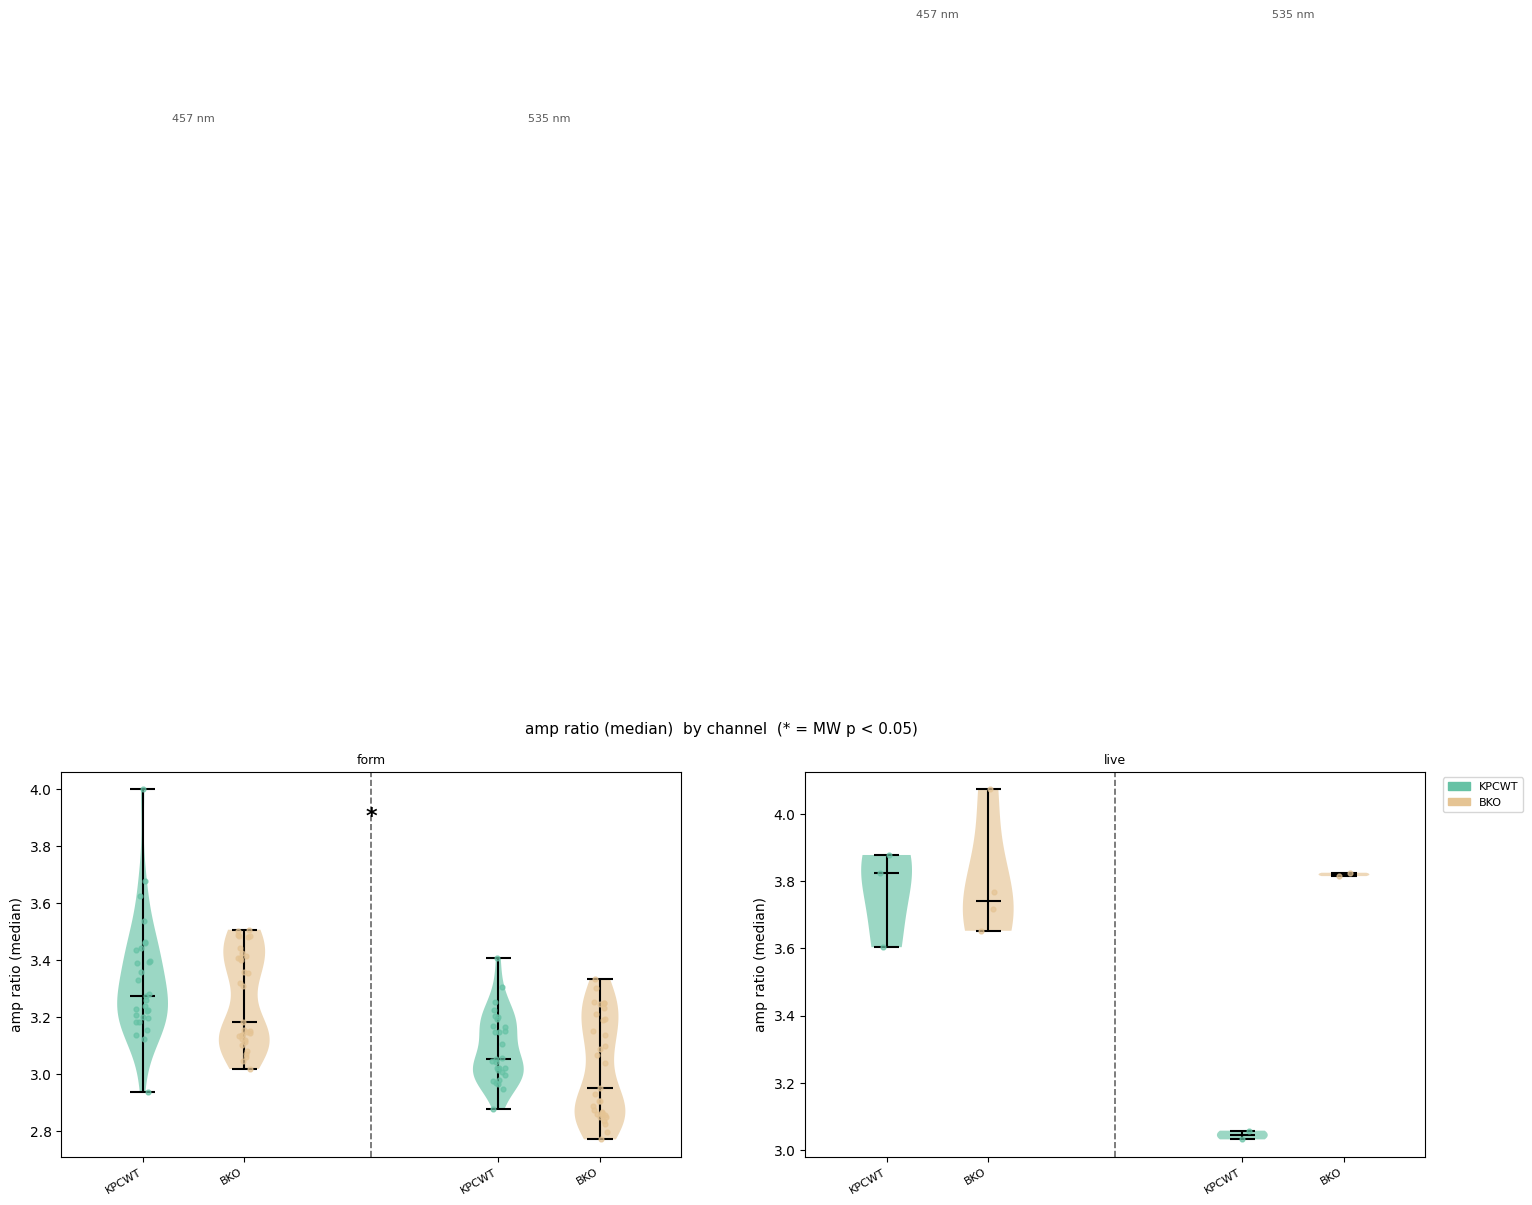

C:\Users\hyeonho\AppData\Local\Temp\ipykernel_10500\139722550.py:97: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [16]:
CHANNEL_METRICS = [m for m in ["amp_ratio_median", "tau_mean_median_ps"]
                   if m in df.columns]

channels = sorted(df_analysis["em_filter_nm"].dropna().unique())

if len(channels) < 2:
    print("Only one emission channel in data -- skipping per-channel comparison.")
elif not CHANNEL_METRICS:
    print("No fit metrics available -- run Phase E first.")
else:
    for metric in CHANNEL_METRICS:
        label   = METRIC_LABELS.get(metric, metric)
        n_fix   = len(fix_present)
        n_ct    = len(ct_present)
        n_ch    = len(channels)
        # positions: channel 0 at 0..n_ct-1, channel 1 at n_ct+1..2*n_ct,
        # with a gap of 2 between groups; dashed line at x = n_ct - 0.5 + 1
        gap     = 1.5
        ch_offsets = [i * (n_ct + gap) for i in range(n_ch)]

        fig, axes = plt.subplots(1, n_fix, figsize=(max(5, 2.2 * n_ct * n_ch) * n_fix, 5),
                                 squeeze=False)

        for ax, fix_type in zip(axes[0], fix_present):
            all_vals_by_ch = {}   # ch -> pooled values for channel-level significance

            for ci, ch in enumerate(channels):
                sub = (df_analysis[(df_analysis["fixation_type"] == fix_type) &
                                   (df_analysis["em_filter_nm"]  == ch) &
                                   df_analysis["cell_type"].isin(ct_present)]
                                  .dropna(subset=[metric]))
                cts_here = [ct for ct in ct_present
                            if (sub["cell_type"] == ct).any()]
                all_vals_by_ch[ch] = sub[metric].values

                rng = np.random.default_rng(seed=ci)
                for j, ct in enumerate(cts_here):
                    grp  = sub[sub["cell_type"] == ct][metric].values
                    pos  = ch_offsets[ci] + j
                    col  = ct_color[ct]
                    if len(grp) >= 2:
                        parts = ax.violinplot([grp], positions=[pos],
                                              showmedians=True, showextrema=True)
                        for pc in parts["bodies"]:
                            pc.set_facecolor(col); pc.set_alpha(0.65)
                        for key2 in ("cmedians", "cbars", "cmins", "cmaxes"):
                            if key2 in parts:
                                parts[key2].set_color("k")
                    elif len(grp) == 1:
                        ax.plot(pos, grp[0], "o", color=col, ms=8, zorder=4)
                    if len(grp) > 0:
                        ax.scatter(pos + rng.uniform(-0.07, 0.07, len(grp)),
                                   grp, s=12, color=col, alpha=0.7, zorder=5)

            # Dashed separator between channel groups
            sep_x = ch_offsets[0] + n_ct - 0.5 + gap * 0.5
            ylo, yhi = ax.get_ylim()
            ax.axvline(sep_x, color="0.4", lw=1.2, ls="--", zorder=1)

            # Channel significance: Mann-Whitney between the two channel pools
            vals_ch = [all_vals_by_ch.get(ch, np.array([])) for ch in channels]
            if len(vals_ch) == 2 and len(vals_ch[0]) >= 3 and len(vals_ch[1]) >= 3:
                mw = stats.mannwhitneyu(vals_ch[0], vals_ch[1], alternative="two-sided")
                if mw.pvalue < FDR_ALPHA:
                    mid_y = ax.get_ylim()[1] * 0.97
                    ax.text(sep_x, mid_y, "*",
                            ha="center", va="top", fontsize=16, fontweight="bold",
                            color="k")

            # X-tick labels: cell-type labels under each violin, channel label above cluster
            tick_pos   = []
            tick_label = []
            for ci, ch in enumerate(channels):
                for j, ct in enumerate(ct_present):
                    tick_pos.append(ch_offsets[ci] + j)
                    tick_label.append(ct)
                mid = ch_offsets[ci] + (n_ct - 1) / 2.0
                ax.text(mid, ax.get_ylim()[0],
                        f"{int(ch)} nm", ha="center", va="top",
                        fontsize=8, color="0.35",
                        transform=ax.get_xaxis_transform())

            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_label, fontsize=8, rotation=30, ha="right")
            ax.set_xlim(ch_offsets[0] - 0.8,
                        ch_offsets[-1] + n_ct - 1 + 0.8)
            ax.set_ylabel(label)
            ax.set_title(fix_type, fontsize=9)

        # Legend: cell type colours
        handles_leg = [mpatches.Patch(color=ct_color[ct], label=ct)
                       for ct in ct_present]
        axes[0][-1].legend(handles=handles_leg, fontsize=8,
                           bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.suptitle(f"{label}  by channel  (* = MW p < {FDR_ALPHA})", fontsize=11)
        plt.tight_layout()
        _savefig(fig, f"fig_channel_{metric}")
        plt.show()

## Step 25b: Per-channel comparison -- points colored by imaging session

Same violin layout as Step 25 (cell_type x channel x fixation_type), but
scatter points are colored by session_root instead of cell_type.
Reveals whether a group difference is driven by a single session.

C:\Users\hyeonho\AppData\Local\Temp\ipykernel_10500\2785366047.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


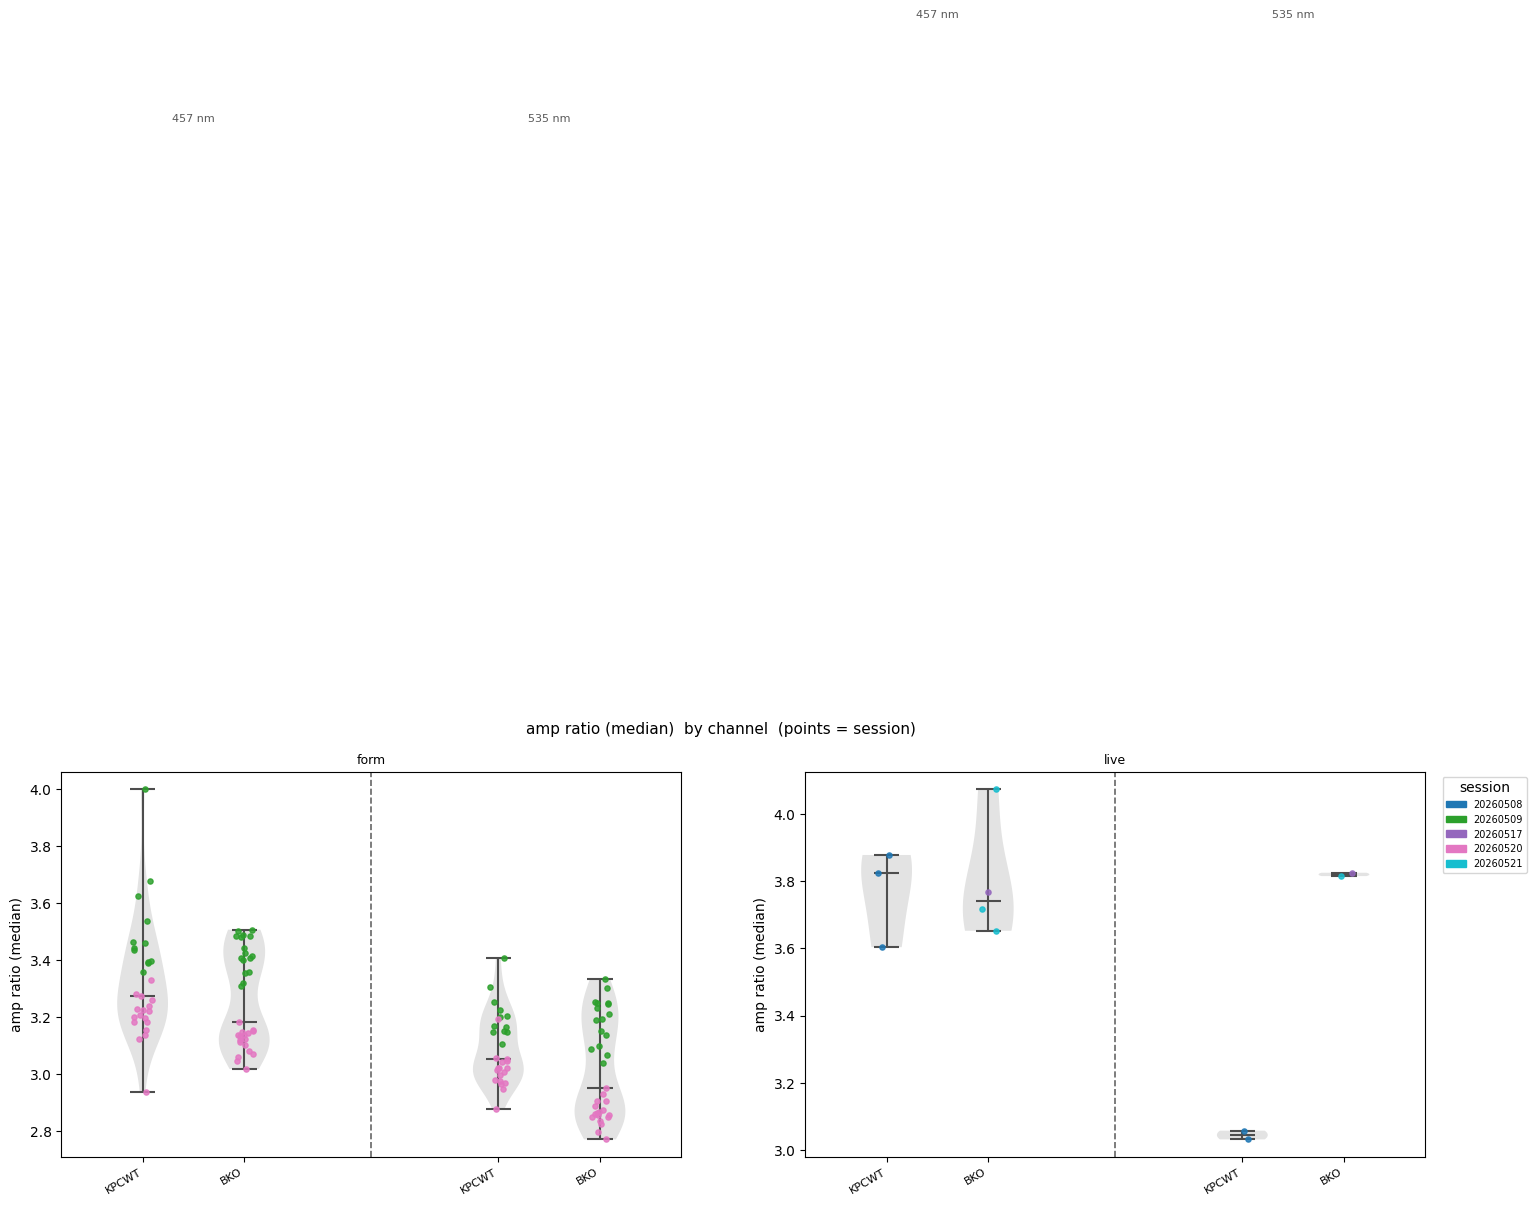

C:\Users\hyeonho\AppData\Local\Temp\ipykernel_10500\2785366047.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [17]:
if len(channels) >= 2 and CHANNEL_METRICS and "session_root" in df_analysis.columns:
    sessions_all = sorted(df_analysis["session_root"].dropna().unique())
    sess_cmap    = plt.cm.tab10(np.linspace(0, 0.9, max(len(sessions_all), 1)))
    sess_color   = {s: sess_cmap[i] for i, s in enumerate(sessions_all)}

    for metric in CHANNEL_METRICS:
        label  = METRIC_LABELS.get(metric, metric)
        n_fix  = len(fix_present)
        n_ct   = len(ct_present)
        n_ch   = len(channels)
        gap    = 1.5
        ch_offsets = [i * (n_ct + gap) for i in range(n_ch)]

        fig, axes = plt.subplots(1, n_fix,
                                 figsize=(max(5, 2.2 * n_ct * n_ch) * n_fix, 5),
                                 squeeze=False)

        for ax, fix_type in zip(axes[0], fix_present):
            for ci, ch in enumerate(channels):
                sub = (df_analysis[(df_analysis["fixation_type"] == fix_type) &
                                   (df_analysis["em_filter_nm"]  == ch) &
                                   df_analysis["cell_type"].isin(ct_present)]
                                  .dropna(subset=[metric]))

                for j, ct in enumerate(ct_present):
                    grp = sub[sub["cell_type"] == ct]
                    pos = ch_offsets[ci] + j
                    vals = grp[metric].values
                    if len(vals) >= 2:
                        parts = ax.violinplot([vals], positions=[pos],
                                              showmedians=True, showextrema=True)
                        for pc in parts["bodies"]:
                            pc.set_facecolor("0.80")
                            pc.set_alpha(0.55)
                        for key2 in ("cmedians", "cbars", "cmins", "cmaxes"):
                            if key2 in parts:
                                parts[key2].set_color("0.3")
                    elif len(vals) == 1:
                        ax.plot(pos, vals[0], "o", color="0.5", ms=8, zorder=4)

                    # Scatter points colored by session
                    rng25b = np.random.default_rng(seed=ci * 100 + j)
                    for sess in sessions_all:
                        sv = grp[grp["session_root"] == sess][metric].values
                        if len(sv) == 0:
                            continue
                        jit = rng25b.uniform(-0.09, 0.09, len(sv))
                        ax.scatter(pos + jit, sv, s=14,
                                   color=sess_color[sess],
                                   alpha=0.85, zorder=5,
                                   label=sess if (ci == 0 and j == 0) else "_")

            # Channel separator
            sep_x = ch_offsets[0] + n_ct - 0.5 + gap * 0.5
            ax.axvline(sep_x, color="0.4", lw=1.2, ls="--", zorder=1)

            # X-ticks: cell_type under each violin, channel label above group
            tick_pos, tick_label = [], []
            for ci, ch in enumerate(channels):
                for j, ct in enumerate(ct_present):
                    tick_pos.append(ch_offsets[ci] + j)
                    tick_label.append(ct)
                mid = ch_offsets[ci] + (n_ct - 1) / 2.0
                ax.text(mid, ax.get_ylim()[0],
                        f"{int(ch)} nm", ha="center", va="top",
                        fontsize=8, color="0.35",
                        transform=ax.get_xaxis_transform())

            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_label, fontsize=8, rotation=30, ha="right")
            ax.set_xlim(ch_offsets[0] - 0.8, ch_offsets[-1] + n_ct - 1 + 0.8)
            ax.set_ylabel(label)
            ax.set_title(fix_type, fontsize=9)

        # Legend: session colours
        handles_sess = [mpatches.Patch(color=sess_color[s],
                                       label=s.split("_")[0])  # date prefix only
                        for s in sessions_all]
        axes[0][-1].legend(handles=handles_sess, fontsize=7,
                           bbox_to_anchor=(1.02, 1), loc="upper left",
                           title="session")

        fig.suptitle(f"{label}  by channel  (points = session)", fontsize=11)
        plt.tight_layout()
        _savefig(fig, f"fig_channel_session_{metric}")
        plt.show()
else:
    print("Step 25b: session_root or channel data not available -- skipping.")

## Step 26: Within-image heterogeneity

Coefficient of variation (CV = std/mean) of tau_mean and amplitude ratio
per image. High CV indicates spatially heterogeneous metabolism within a
field of view. Compare BKO vs KPCWT to test whether KO affects metabolic
uniformity, not just mean level.

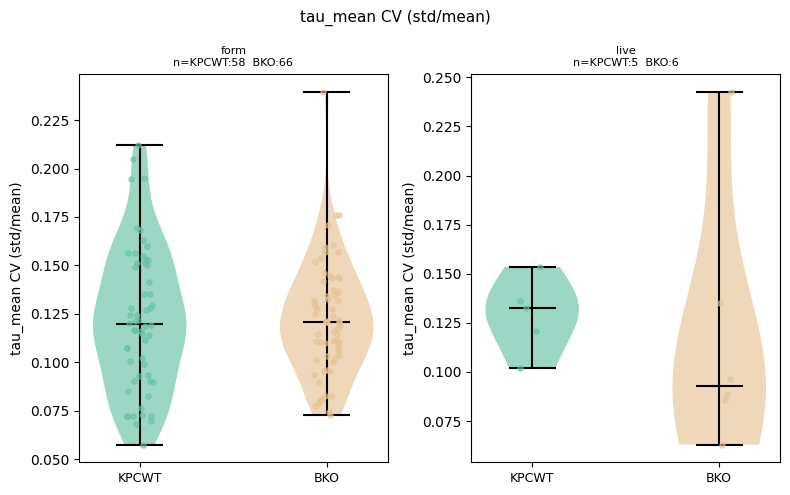

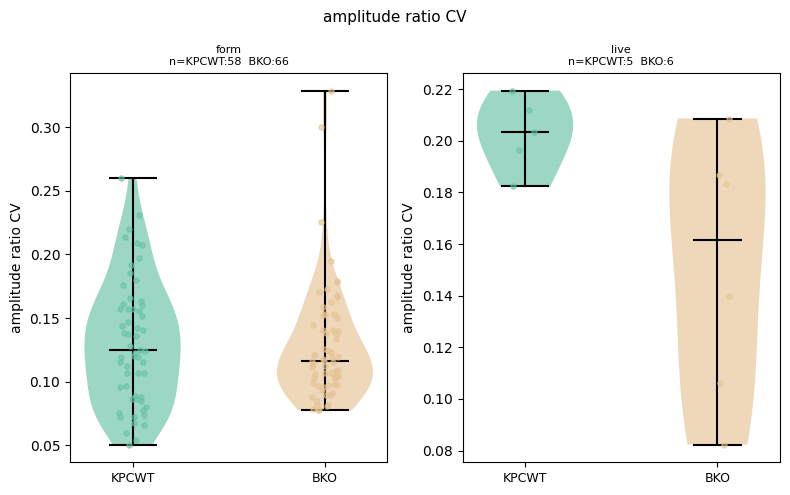

In [18]:
CV_METRICS = {
    "tau_mean_cv":  "tau_mean CV (std/mean)",
    "amp_ratio_cv": "amplitude ratio CV",
}
cv_cols = [c for c in CV_METRICS if c in df.columns]

if not cv_cols:
    print("CV columns not found -- re-run Phase E Step 18 to compute them.")
else:
    for cv_col in cv_cols:
        label = CV_METRICS[cv_col]
        fig, axes = plt.subplots(1, len(fix_present),
                                 figsize=(4 * len(fix_present), 5),
                                 squeeze=False)
        for ax, fix_type in zip(axes[0], fix_present):
            sub = (df_analysis[(df_analysis["fixation_type"] == fix_type) &
                               df_analysis["cell_type"].isin(ct_present)]
                              .dropna(subset=[cv_col]))
            cts_here = [ct for ct in ct_present
                        if (sub["cell_type"] == ct).any()]
            groups   = [sub[sub["cell_type"] == ct][cv_col].values
                        for ct in cts_here]
            colors   = [ct_color[ct] for ct in cts_here]

            if groups:
                parts = ax.violinplot(groups,
                                      positions=range(len(groups)),
                                      showmedians=True, showextrema=True)
                for pc, c in zip(parts["bodies"], colors):
                    pc.set_facecolor(c); pc.set_alpha(0.65)
                for key2 in ("cmedians", "cbars", "cmins", "cmaxes"):
                    if key2 in parts:
                        parts[key2].set_color("k")
                rng = np.random.default_rng(seed=0)
                for j, (grp, c) in enumerate(zip(groups, colors)):
                    ax.scatter(j + rng.uniform(-0.07, 0.07, len(grp)),
                               grp, s=14, color=c, alpha=0.6, zorder=3)
                ax.set_xticks(range(len(cts_here)))
                ax.set_xticklabels(cts_here, fontsize=9)

            n_str = "  ".join(f"{ct}:{(sub['cell_type']==ct).sum()}"
                              for ct in cts_here)
            ax.set_title(f"{fix_type}\nn={n_str}", fontsize=8)
            ax.set_ylabel(label)

        fig.suptitle(label, fontsize=11)
        plt.tight_layout()
        _savefig(fig, f"fig_heterogeneity_{cv_col}")
        plt.show()

## Step 27: Sample size table

N images per (fixation_type x cell_type x channel). Used for the methods
slide and to flag underpowered groups before interpreting statistics.

Sample sizes (N images):
cell_type                   KPCWT  BKO
fixation_type em_filter_nm            
form          457.0            29   33
              535.0            29   33
live          457.0             3    4
              535.0             2    2


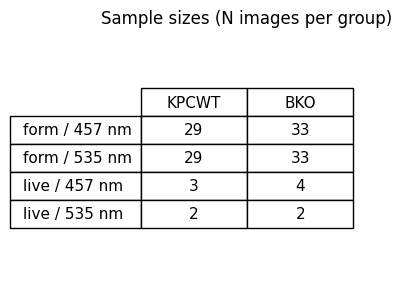

Saved: ..\results\sample_sizes.csv


In [19]:
size_tbl = (df_analysis[df_analysis["cell_type"].isin(ct_present)]
            .groupby(["fixation_type", "cell_type", "em_filter_nm"],
                     dropna=False)
            .size()
            .reset_index(name="n_images"))

# Pivot for readability: rows = fixation x channel, cols = cell_type
if not size_tbl.empty:
    pivot = size_tbl.pivot_table(
        index=["fixation_type", "em_filter_nm"],
        columns="cell_type",
        values="n_images",
        aggfunc="sum",
        fill_value=0,
    )
    # Enforce column order
    col_order = [c for c in CELL_TYPE_ORDER if c in pivot.columns]
    pivot = pivot[col_order]
    print("Sample sizes (N images):")
    print(pivot.to_string())

    # Visual table as a matplotlib figure
    row_labels = [f"{ft} / {int(ch) if not pd.isna(ch) else 'NA'} nm"
                  for ft, ch in pivot.index]
    cell_text  = pivot.values.tolist()
    col_labels = list(pivot.columns)

    fig, ax = plt.subplots(figsize=(max(4, 1.6 * len(col_labels)),
                                    max(2, 0.45 * len(row_labels) + 1.2)))
    ax.axis("off")
    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.6)
    ax.set_title("Sample sizes (N images per group)", fontsize=12, pad=10)
    plt.tight_layout()
    _savefig(fig, "fig_sample_sizes")
    plt.show()

    size_tbl.to_csv(results_dir / "sample_sizes.csv", index=False)
    print(f"Saved: {results_dir / 'sample_sizes.csv'}")

## Summary

Phase F complete.

Step 20 -- Photobleaching: if tau_mean or G_cal drift systematically within
  a session, consider splitting the session or excluding late-acquired images.

Step 21 -- Violins: each point is one field of view (one image).
  Spread reflects true biological variability + measurement noise.

Step 22 -- Statistics: Mann-Whitney U (non-parametric, no normality assumption).
  BH-FDR applied per (fixation_type, metric) block.
  Effect size r = 2U/(n1*n2) - 1: positive = group_a larger than group_b.
  |r| < 0.3 small, 0.3-0.5 medium, > 0.5 large.
  Note: treating each image as an independent replicate is conservative if
  multiple images came from the same dish. Mixed-effects models would be
  needed to account for dish-level clustering.

Step 23 -- Cross-validation: phasor tau_phi should correlate with fit tau_mean.
  Decorrelation suggests a systematic artifact in one method (e.g., IRF
  mismatch, poor chi^2 masking, or calibration error).

Saved:
  results/stat_tests.csv      -- all pairwise Mann-Whitney tests
  results/group_summary.csv   -- group means +/- SEM

---
## Part 2: amp_ratio -- colony annotation and fixation-duration subsets

Four figures showing KPCWT vs BKO amp_ratio_median (shift=0, 2-comp).
Scatter points on each violin are individual image medians.

Fig 1  -- form fixation, all images.
  Panels: 10 min / 20 min / combined  x  457 nm / 535 nm.
  Point color: colony_deep (blue) | peripheral (orange) | unannotated (gray).

Fig 2  -- live, all images.
  Panels: 457 nm / 535 nm.
  Point color: same three-color scheme.

Fig 3  -- form fixation, colony_deep images only.
  Panels: 10 min / 20 min  x  457 nm / 535 nm.
  Points colored by cell_type (colony annotation not needed; all deep).

Fig 4  -- live, colony_deep images only.
  Panels: 457 nm / 535 nm.
  Points colored by cell_type.

treatment_duration is read from sdt_metadata_cal.csv (column already present).
---

In [20]:
# -- Part 2 setup -----------------------------------------------------------

# Merge treatment_duration from sdt_df into df_analysis if not present yet.
# sdt_df was loaded in Step 19 and is still in scope.
if "treatment_duration" not in df_analysis.columns:
    _td_col = (sdt_df[["filename", "treatment_duration"]]
               .drop_duplicates("filename"))
    df_analysis = df_analysis.merge(_td_col, on="filename", how="left")
    df_analysis["treatment_duration"] = (
        df_analysis["treatment_duration"].fillna("").astype(str)
    )

# Colony annotation categories and colors
_CAT_DEEP   = "colony_deep"
_CAT_PERIPH = "peripheral"
_CAT_UNANN  = "unannotated"
_CAT_COLORS = {
    _CAT_DEEP:   "#4393c3",   # blue
    _CAT_PERIPH: "#d6604d",   # orange-red
    _CAT_UNANN:  "#aaaaaa",   # gray
}

# Annotate every row in df_analysis
df_analysis["_colony_cat"] = df_analysis["position_annotation"].apply(
    lambda x: _CAT_DEEP   if x == "colony_deep"
              else (_CAT_PERIPH if x in ("colony_edge", "colony_island")
                    else _CAT_UNANN)
)

# Boolean masks (applied to df_analysis which is already shift=0, 2-comp filtered)
_M_FORM_10  = (df_analysis["fixation_type"] == "form") & (df_analysis["treatment_duration"] == "10min")
_M_FORM_20  = (df_analysis["fixation_type"] == "form") & (df_analysis["treatment_duration"] == "20min")
_M_FORM_ALL = (df_analysis["fixation_type"] == "form")
_M_LIVE_ALL = (df_analysis["fixation_type"] == "live")
_M_DEEP     = (df_analysis["position_annotation"] == "colony_deep")

_P2_CHANNELS = sorted(df_analysis["em_filter_nm"].dropna().unique())
_P2_CT       = [c for c in ["KPCWT", "BKO"] if c in ct_present]
_P2_METRIC   = "amp_ratio_median"

print("treatment_duration distribution (form only):")
print(df_analysis[_M_FORM_ALL]["treatment_duration"].value_counts(dropna=False).to_string())
print()
print(f"Form 10 min : {_M_FORM_10.sum()} rows")
print(f"Form 20 min : {_M_FORM_20.sum()} rows")
print(f"Form combined: {_M_FORM_ALL.sum()} rows")
print(f"Live         : {_M_LIVE_ALL.sum()} rows")
print()
print("Colony annotation counts (df_analysis):")
print(df_analysis["_colony_cat"].value_counts(dropna=False).to_string())

treatment_duration distribution (form only):
treatment_duration
10min    68
20min    56

Form 10 min : 68 rows
Form 20 min : 56 rows
Form combined: 124 rows
Live         : 11 rows

Colony annotation counts (df_analysis):
_colony_cat
colony_deep    94
peripheral     57
unannotated    31


In [21]:
# -- Helper: draw one violin + scatter panel --------------------------------
#
# Draws gray violins (so colored scatter is legible), then overlays scatter
# points.  When point_col / color_map are given, scatter is colored by that
# column; otherwise points use the ct_color palette (for deep-only figures).

def _p2_amp_panel(ax, df_sub, group_order, metric=_P2_METRIC,
                  point_col=None, color_map=None, min_n=2, title=""):
    """Violin + scatter for one subplot.  Returns n-string for title."""
    _sub = df_sub[df_sub["cell_type"].isin(group_order)].dropna(subset=[metric])
    _gs  = [g for g in group_order if (_sub["cell_type"] == g).sum() >= min_n]
    if not _gs:
        ax.text(0.5, 0.5, "no data (n<2)", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
        ax.set_title(title, fontsize=8)
        return ""

    # Gray violin per group
    _valid = [(i, _sub[_sub["cell_type"] == g][metric].values)
              for i, g in enumerate(_gs)
              if len(_sub[_sub["cell_type"] == g]) >= min_n]
    if _valid:
        _pts = ax.violinplot([v for _, v in _valid],
                             positions=[i for i, _ in _valid],
                             showmedians=True, showextrema=True)
        for _pc in _pts["bodies"]:
            _pc.set_facecolor("0.82"); _pc.set_alpha(0.55)
        for _k in ("cmedians", "cbars", "cmins", "cmaxes"):
            if _k in _pts:
                _pts[_k].set_color("0.4"); _pts[_k].set_linewidth(1.2)

    # Scatter points
    _rng = np.random.default_rng(seed=42)
    for _j, _g in enumerate(_gs):
        _grp = _sub[_sub["cell_type"] == _g]
        if point_col and color_map:
            for _cat, _col in color_map.items():
                _sv = _grp[_grp[point_col] == _cat][metric].values
                if len(_sv) == 0:
                    continue
                ax.scatter(_j + _rng.uniform(-0.08, 0.08, len(_sv)),
                           _sv, s=20, color=_col, alpha=0.85, zorder=4)
        else:
            _sv = _grp[metric].values
            _col = ct_color.get(_g, "steelblue")
            ax.scatter(_j + _rng.uniform(-0.08, 0.08, len(_sv)),
                       _sv, s=20, color=_col, alpha=0.85, zorder=4)

    ax.set_xticks(range(len(_gs)))
    ax.set_xticklabels(_gs, fontsize=9)
    ax.set_title(title, fontsize=8)
    return "  ".join(f"{g}:{(_sub['cell_type'] == g).sum()}" for g in _gs)

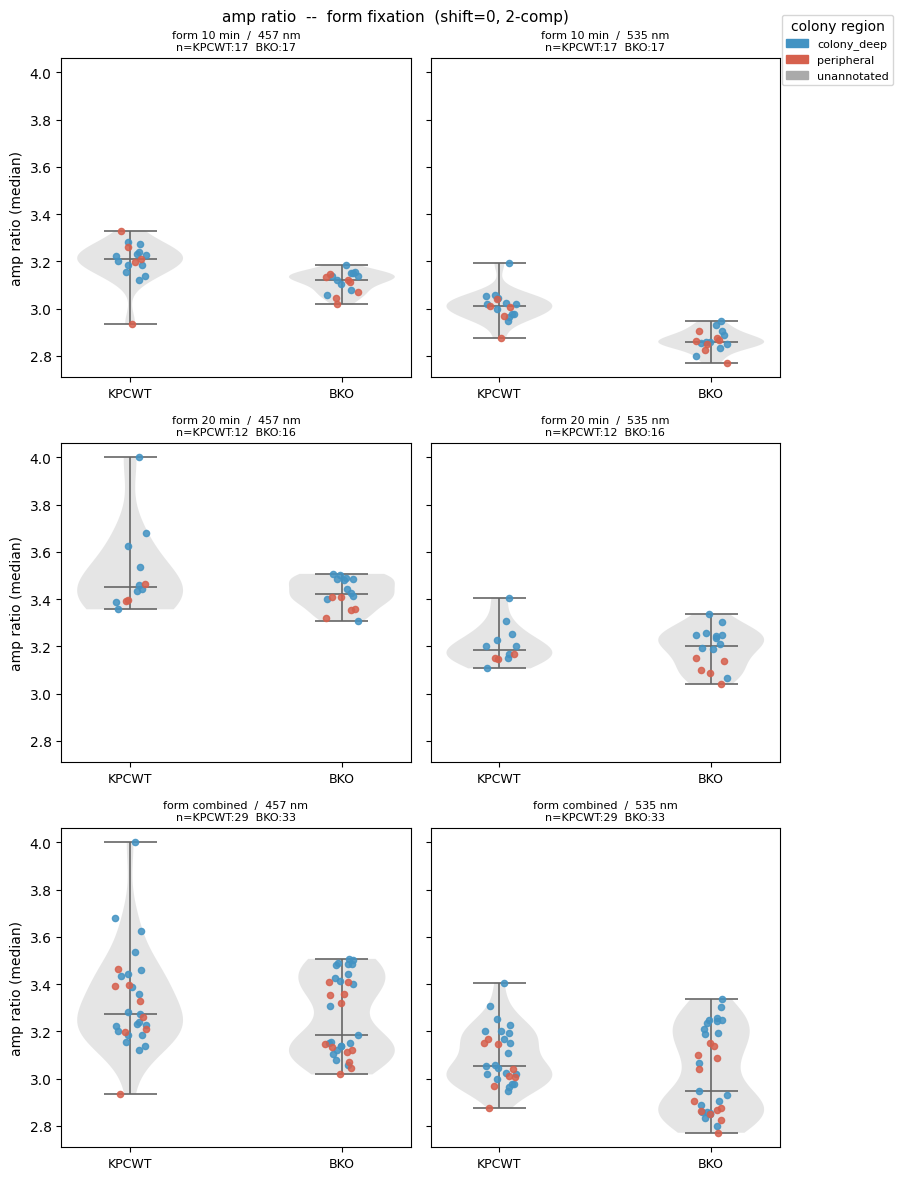

In [22]:
# -- Figure 1: form fixation, all colony annotations ----------------------
#   Layout: rows = fixation duration (10min / 20min / combined)
#           cols = emission channel

_dur_sets_1 = [
    ("form 10 min",   df_analysis[_M_FORM_10]),
    ("form 20 min",   df_analysis[_M_FORM_20]),
    ("form combined", df_analysis[_M_FORM_ALL]),
]
_nrows_1 = len(_dur_sets_1)
_ncols_1 = len(_P2_CHANNELS)

_fig1, _axes1 = plt.subplots(_nrows_1, _ncols_1,
                              figsize=(4*_ncols_1, 4*_nrows_1),
                              squeeze=False, sharey=True)

for _ri1, (_dur_lbl, _df_dur) in enumerate(_dur_sets_1):
    for _ci1, _ch1 in enumerate(_P2_CHANNELS):
        _ax1 = _axes1[_ri1][_ci1]
        _df_ch = _df_dur[_df_dur["em_filter_nm"] == _ch1]
        _ns1 = _p2_amp_panel(
            _ax1, _df_ch, _P2_CT,
            point_col="_colony_cat", color_map=_CAT_COLORS,
            title=f"{_dur_lbl}  /  {int(_ch1)} nm",
        )
        if _ns1:
            _ax1.set_title(f"{_dur_lbl}  /  {int(_ch1)} nm\nn={_ns1}", fontsize=8)
        if _ci1 == 0:
            _ax1.set_ylabel("amp ratio (median)")

_leg1 = [mpatches.Patch(color=v, label=k) for k, v in _CAT_COLORS.items()]
_fig1.legend(handles=_leg1, title="colony region", fontsize=8,
             loc="upper right", bbox_to_anchor=(1.13, 0.98))
_fig1.suptitle("amp ratio  --  form fixation  (shift=0, 2-comp)",
               fontsize=11)
plt.tight_layout()
_savefig(_fig1, "fig_amp_form_colony_color")
plt.show()

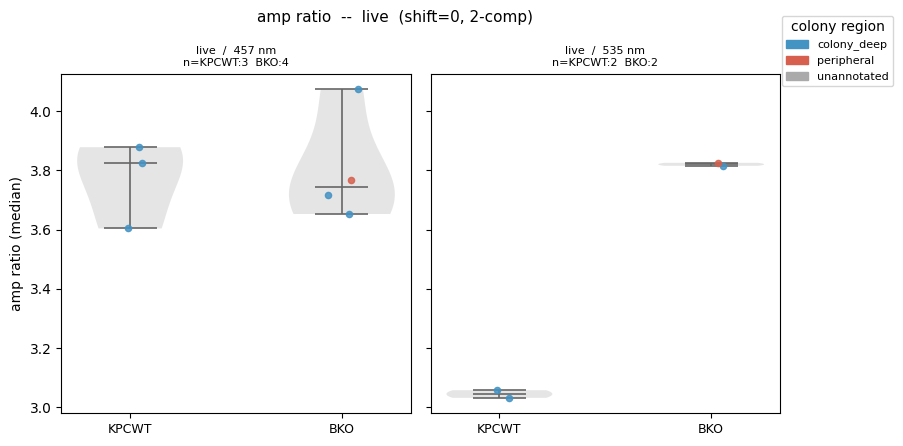

In [23]:
# -- Figure 2: live, all colony annotations --------------------------------
#   Layout: 1 row x 2 cols (channels)

_nrows_2 = 1
_ncols_2 = len(_P2_CHANNELS)

_fig2, _axes2 = plt.subplots(_nrows_2, _ncols_2,
                              figsize=(4*_ncols_2, 4.5),
                              squeeze=False, sharey=True)

for _ci2, _ch2 in enumerate(_P2_CHANNELS):
    _ax2  = _axes2[0][_ci2]
    _df_ch2 = df_analysis[_M_LIVE_ALL & (df_analysis["em_filter_nm"] == _ch2)]
    _ns2 = _p2_amp_panel(
        _ax2, _df_ch2, _P2_CT,
        point_col="_colony_cat", color_map=_CAT_COLORS,
        title=f"live  /  {int(_ch2)} nm",
    )
    if _ns2:
        _ax2.set_title(f"live  /  {int(_ch2)} nm\nn={_ns2}", fontsize=8)
    if _ci2 == 0:
        _ax2.set_ylabel("amp ratio (median)")

_leg2 = [mpatches.Patch(color=v, label=k) for k, v in _CAT_COLORS.items()]
_fig2.legend(handles=_leg2, title="colony region", fontsize=8,
             loc="upper right", bbox_to_anchor=(1.13, 0.98))
_fig2.suptitle("amp ratio  --  live  (shift=0, 2-comp)", fontsize=11)
plt.tight_layout()
_savefig(_fig2, "fig_amp_live_colony_color")
plt.show()

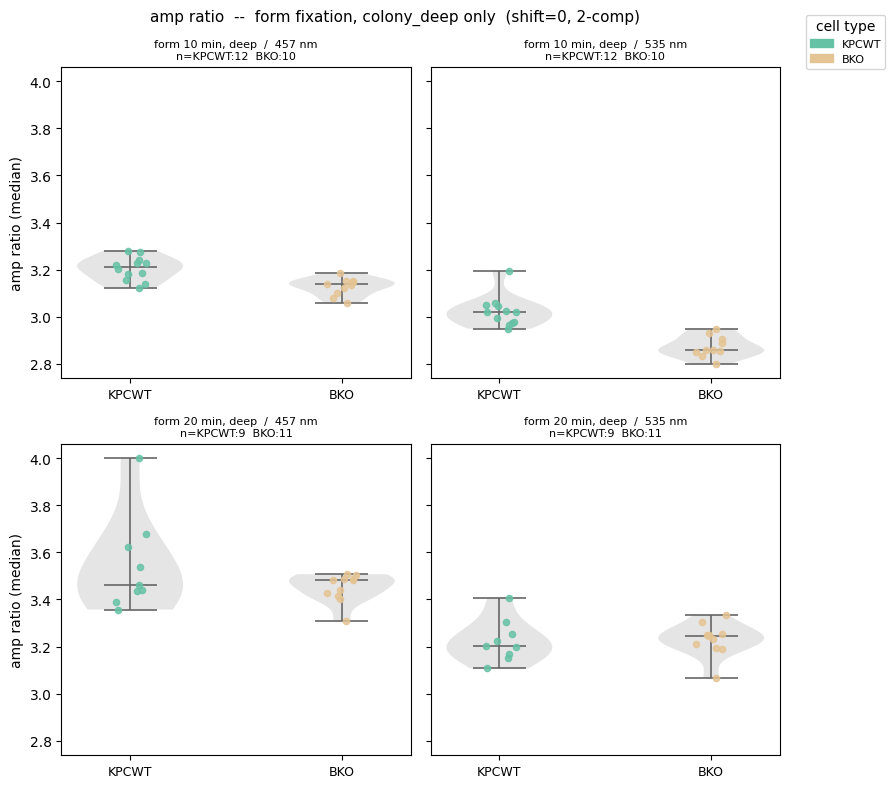

In [24]:
# -- Figure 3: form fixation, colony_deep only -----------------------------
#   Layout: rows = fixation duration (10min / 20min)
#           cols = emission channel
#   No combined panel (10min and 20min are compared separately for deep cells)

_dur_sets_3 = [
    ("form 10 min, deep", df_analysis[_M_FORM_10 & _M_DEEP]),
    ("form 20 min, deep", df_analysis[_M_FORM_20 & _M_DEEP]),
]
_nrows_3 = len(_dur_sets_3)
_ncols_3 = len(_P2_CHANNELS)

_fig3, _axes3 = plt.subplots(_nrows_3, _ncols_3,
                              figsize=(4*_ncols_3, 4*_nrows_3),
                              squeeze=False, sharey=True)

for _ri3, (_dur_lbl, _df_dur) in enumerate(_dur_sets_3):
    for _ci3, _ch3 in enumerate(_P2_CHANNELS):
        _ax3 = _axes3[_ri3][_ci3]
        _df_ch3 = _df_dur[_df_dur["em_filter_nm"] == _ch3]
        _ns3 = _p2_amp_panel(
            _ax3, _df_ch3, _P2_CT,
            point_col=None, color_map=None,   # cell_type colors, no colony overlay
            title=f"{_dur_lbl}  /  {int(_ch3)} nm",
        )
        if _ns3:
            _ax3.set_title(f"{_dur_lbl}  /  {int(_ch3)} nm\nn={_ns3}", fontsize=8)
        if _ci3 == 0:
            _ax3.set_ylabel("amp ratio (median)")

# Cell-type legend
_leg3 = [mpatches.Patch(color=ct_color.get(c, "gray"), label=c) for c in _P2_CT]
_fig3.legend(handles=_leg3, title="cell type", fontsize=8,
             loc="upper right", bbox_to_anchor=(1.12, 0.98))
_fig3.suptitle("amp ratio  --  form fixation, colony_deep only  (shift=0, 2-comp)",
               fontsize=11)
plt.tight_layout()
_savefig(_fig3, "fig_amp_form_deep_only")
plt.show()

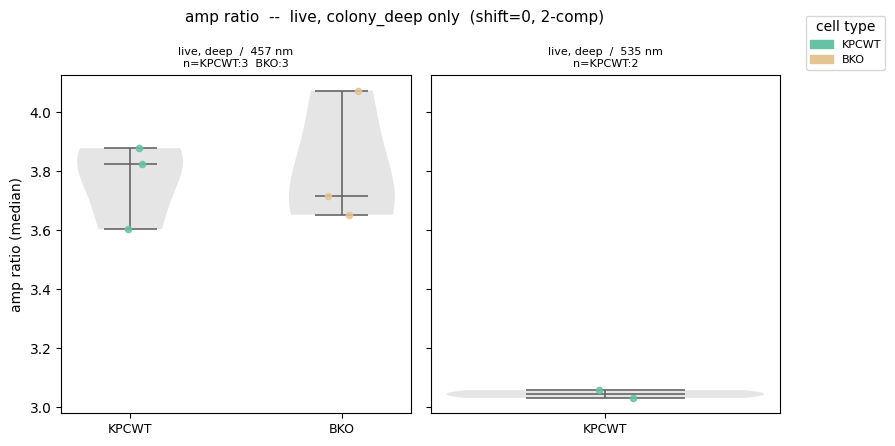

In [25]:
# -- Figure 4: live, colony_deep only --------------------------------------
#   Layout: 1 row x 2 cols (channels)

_nrows_4 = 1
_ncols_4 = len(_P2_CHANNELS)

_fig4, _axes4 = plt.subplots(_nrows_4, _ncols_4,
                              figsize=(4*_ncols_4, 4.5),
                              squeeze=False, sharey=True)

for _ci4, _ch4 in enumerate(_P2_CHANNELS):
    _ax4 = _axes4[0][_ci4]
    _df_ch4 = df_analysis[_M_LIVE_ALL & _M_DEEP & (df_analysis["em_filter_nm"] == _ch4)]
    _ns4 = _p2_amp_panel(
        _ax4, _df_ch4, _P2_CT,
        point_col=None, color_map=None,
        title=f"live, deep only  /  {int(_ch4)} nm",
    )
    if _ns4:
        _ax4.set_title(f"live, deep  /  {int(_ch4)} nm\nn={_ns4}", fontsize=8)
    if _ci4 == 0:
        _ax4.set_ylabel("amp ratio (median)")

_leg4 = [mpatches.Patch(color=ct_color.get(c, "gray"), label=c) for c in _P2_CT]
_fig4.legend(handles=_leg4, title="cell type", fontsize=8,
             loc="upper right", bbox_to_anchor=(1.12, 0.98))
_fig4.suptitle("amp ratio  --  live, colony_deep only  (shift=0, 2-comp)",
               fontsize=11)
plt.tight_layout()
_savefig(_fig4, "fig_amp_live_deep_only")
plt.show()

In [26]:
import winsound as _ws, time as _t
for _ in range(3):
    _ws.Beep(1000, 400)
    _t.sleep(1)